[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MarcoBattiato/PH6721-Deep-Learning-with-Python/blob/main/Classes/Class_2/02A-RegressionAndSupervisedLearning.ipynb)

# 02A — Regression and the Supervised Learning Framework
(by Marco Battiato. For questions/errors/bugs/typos report, please email at marco.battiato.teaching@gmail.com)

**PH6721 — Deep Learning with Python**

**Class 2, Notebook A — Hour 1**

**Instructor:** Marco Battiato (formerly Nanyang Assistant Professor @ Nanyang Technological University)

**email:**  marco.battiato.teaching@gmail.com

**In Person Classes:**  Wednesday 6:30pm - 9:45pm

**Consultation:** remote consultations are to be arranged by writing to marco.battiato.teaching@gmail.com

In the previous class we learned to load, summarise and visualise data.

We could *describe* a dataset, but we could not *predict* anything from it.

This notebook makes that step. It introduces the supervised learning framework that underlies
almost everything in the rest of the course, and then works through its simplest instance:
fitting a straight line to measurements.

The straight line is deliberately simple. The framework around it is not, and it is the part
worth learning carefully.

## Learning Objectives

By the end of this notebook, students should be able to:

- state the supervised learning problem in terms of features, targets, a model and a loss function;
- explain what "fitting a model" means as an optimization problem;
- fit a linear regression by least squares, using NumPy and scikit-learn;
- interpret regression coefficients, including their physical units;
- use residual plots to diagnose whether a model is adequate;
- extend linear regression to several features;
- explain why squared error is the natural loss under Gaussian noise;
- recognise situations where linear regression is the wrong tool.

Section **9.1** is **optional**. It follows section 9's derivation through for a Lorentzian reading
error, which gives a loss that ignores distant outliers outright — and pays for that with a loss
surface that no longer has a single bottom. Nothing later in the course depends on it.

## Where this sits in the pipeline

Every supervised project in this course runs the same ten steps, and each notebook fills a few of
them. The map below is that pipeline, with this notebook's steps picked out. It is worth a minute
now: it is the shape your project report will have, and the same picture opens every method
notebook from here on, so what changes between them is visible at a glance.

Read it top to bottom. Boxes stacked vertically happen one after another; boxes side by side
happen together; a step that loops carries a return arrow.

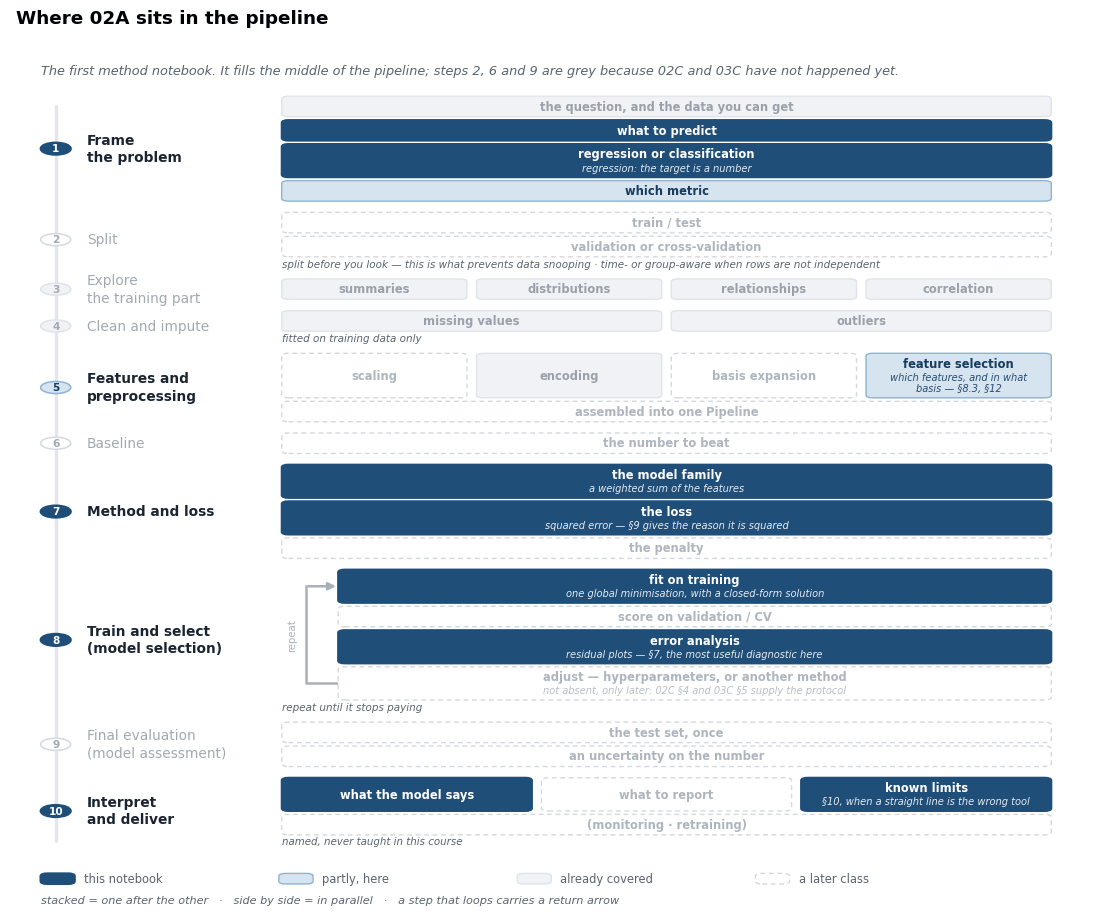

In [ ]:
# Infrastructure, not material. The map below is drawn by one helper file kept with
# the course; Colab has no copy of the repository, so fetch it when it is not already here.
import os, sys, urllib.request
import matplotlib.pyplot as plt

for folder in (".", "..", "../.."):
    if os.path.exists(f"{folder}/pipeline_map.py"):
        sys.path.insert(0, folder)
        break
else:
    urllib.request.urlretrieve("https://raw.githubusercontent.com/MarcoBattiato/"
                               "PH6721-Deep-Learning-with-Python/main/pipeline_map.py",
                               "pipeline_map.py")
from pipeline_map import pipeline_map

pipeline_map(
    {"1.1": "done", "1.2": "now", "1.3": "now", "1.4": "part", "3": "done", "4": "done",
     "5.4": "part", "7.1": "now", "7.2": "now", "8.1": "now", "8.3": "now", "10.1": "now",
     "10.3": "now",
     "5.after": "next",
     "5.2": "done"},
    notes={"1.3": "regression: the target is a number",
           "8.4": "not absent, only later: 02C §4 and 03C §5 supply the protocol",
           "5.4": "which features, and in what basis — §8.3, §12",
           "7.1": "a weighted sum of the features",
           "7.2": "squared error — §9 gives the reason it is squared",
           "8.1": "one global minimisation, with a closed-form solution",
           "8.3": "residual plots — §7, the most useful diagnostic here",
           "10.3": "§10, when a straight line is the wrong tool"},
    title="Where 02A sits in the pipeline",
    lead="The first method notebook. It fills the middle of the pipeline; steps 2, 6 and 9 "
         "are grey because 02C and 03C have not happened yet.")
plt.show()

Two things to take from the map rather than from the section headings.

**The step worth remembering is 8.** Every method in Classes 2 and 3 fits in **one global
minimisation** — squared error has a closed-form solution, so there is no search and no starting
point to get stuck at. `04A`'s tree is the first method that cannot do this, and almost everything
unusual about trees follows from that.

**The grey at the top and bottom is the honest part.** Steps 2, 6 and 9 — split, baseline, final
evaluation — are missing from this notebook, so every number it reports is computed on the data the
model was fitted to. `02C` supplies the split, and `03C` §8 assembles all ten steps into runnable
code.

# 1. From describing data to predicting

In notebooks `01C` and `01D` we asked questions such as:

- What does this dataset contain?
- How are the variables distributed?
- Which variables are related?

These are **descriptive** questions. They are about the data we already have.

Now we ask a different kind of question:

> Given the measurements we have collected, can we predict the value of some quantity for a **new** observation we have not seen?

This is a **predictive** question, and it is the subject of supervised learning.

The shift matters more than it may appear. A description only has to be faithful to the data in
front of us. A prediction has to be right about data that does not exist yet.

# 2. The supervised learning framework

Nearly every supervised method in this course fits the same template. Learning the template once
means that later methods differ only in their details.

## 2.1 Features and targets

We have $n$ observations. For each observation $i$ we have:

- a vector of **features** (also called inputs, predictors, or covariates)

$$
\mathbf{x}_i = (x_{i1}, x_{i2}, \ldots, x_{ip})
$$

- a **target** (also called the label, output, or response)

$$
y_i
$$

In the language of notebook `01C`: features are the columns we measure, and the target is the
column we want to predict.

The whole dataset is written as a matrix $\mathbf{X}$ of shape $(n, p)$ and a vector
$\mathbf{y}$ of length $n$.

Two distinct problems are covered by this notation:

| Target type | Problem | Example |
|---|---|---|
| Continuous number | **Regression** | Predict a material's band gap |
| Category | **Classification** | Predict which species a flower belongs to |

This notebook is about regression. The next notebook, `02B`, is about classification.

## 2.2 What a model is

A **model** is a family of functions, indexed by parameters $\boldsymbol{\theta}$:

$$
f_{\boldsymbol{\theta}} : \mathbf{x} \mapsto \hat{y}
$$

Choosing a model means choosing what shapes of relationship we are willing to consider.

For a straight line through one feature, the parameters are a slope and an intercept:

$$
f_{\boldsymbol{\theta}}(x) = \theta_1 x + \theta_0
$$

This is a very restrictive family. It contains every straight line, and nothing else. If the true
relationship is curved, no choice of $\theta_0$ and $\theta_1$ will represent it.

That restriction is the model's **inductive bias**, the idea introduced in notebook `01A`.

## 2.3 What a loss function is

Given parameters, we need a number saying how badly the model fits the data.

That number is the **loss**. For regression, the standard choice is the **mean squared error**:

$$
L(\boldsymbol{\theta}) = \frac{1}{n} \sum_{i=1}^{n} \bigl(y_i - f_{\boldsymbol{\theta}}(\mathbf{x}_i)\bigr)^2
$$

Each term measures how far the prediction is from the observed value. Squaring makes the errors
positive and penalises large errors disproportionately.

Section 9 explains why squaring specifically, rather than taking absolute values.

## 2.4 Training is optimization

**Training** or **fitting** a model means searching for the parameters that make the loss small:

$$
\hat{\boldsymbol{\theta}} = \arg\min_{\boldsymbol{\theta}} \; L(\boldsymbol{\theta})
$$

That is the entire idea. Every supervised method in this course is some version of:

1. choose a family of functions;
2. choose a loss that measures misfit;
3. search for the parameters minimising that loss.

Linear regression is the case where all three steps have a clean answer. Neural networks, in
Class 7, use the same three steps, but the search must be done numerically.

There is a fourth step, and it is the one beginners skip:

4. check whether the fitted model is any good **on data it was not fitted to**.

Notebook `02C`, the next one, is devoted entirely to step 4.

The four steps form a loop, and it is worth having the picture in mind because every supervised
method in this course is some traversal of it.

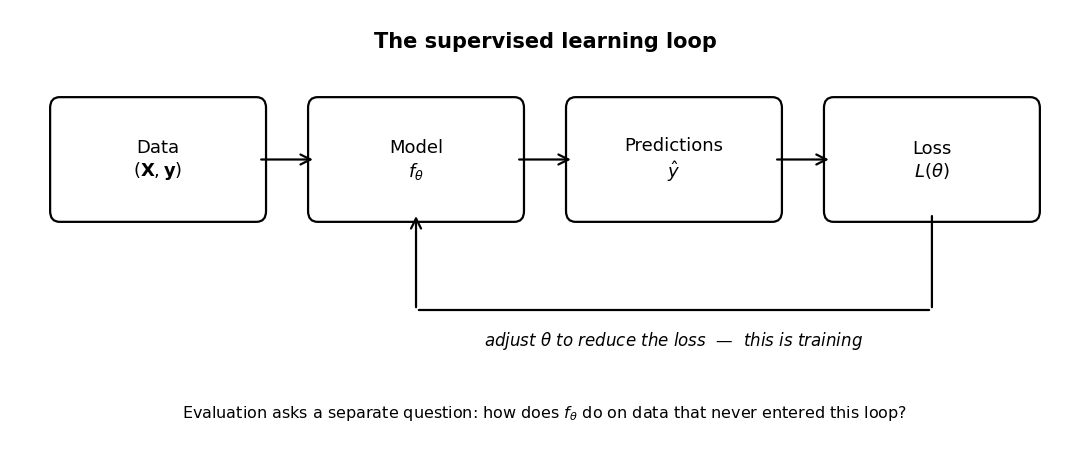

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(11, 4.6))

boxes = [
    (0.3,  2.0, "Data\n$(\\mathbf{X}, \\mathbf{y})$"),
    (3.0,  2.0, "Model\n$f_{\\theta}$"),
    (5.7,  2.0, "Predictions\n$\\hat{y}$"),
    (8.4,  2.0, "Loss\n$L(\\theta)$"),
]
w, h = 2.1, 1.0

for x, y, label in boxes:
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.08,rounding_size=0.1",
                                linewidth=1.6, facecolor="white", edgecolor="black"))
    ax.text(x + w/2, y + h/2, label, ha="center", va="center", fontsize=13)

for i in range(len(boxes) - 1):
    ax.add_patch(FancyArrowPatch((boxes[i][0] + w, 2.5), (boxes[i+1][0], 2.5),
                                 arrowstyle="->", mutation_scale=18, linewidth=1.6))

# the feedback edge: adjust the parameters and go round again
ax.add_patch(FancyArrowPatch((9.45, 2.0), (9.45, 1.1), arrowstyle="-", mutation_scale=16, linewidth=1.6))
ax.add_patch(FancyArrowPatch((9.45, 1.1), (4.05, 1.1), arrowstyle="-", mutation_scale=16, linewidth=1.6))
ax.add_patch(FancyArrowPatch((4.05, 1.1), (4.05, 2.0), arrowstyle="->", mutation_scale=18, linewidth=1.6))
ax.text(6.75, 0.82, r"adjust $\theta$ to reduce the loss  —  this is training",
        ha="center", va="center", fontsize=12, style="italic")

ax.text(5.4, 3.55, "The supervised learning loop", ha="center", fontsize=15, fontweight="bold")
ax.text(5.4, 0.15, "Evaluation asks a separate question: how does $f_{\\theta}$ do on data that never entered this loop?",
        ha="center", va="center", fontsize=11.5)

ax.set_xlim(-0.2, 11.0); ax.set_ylim(-0.1, 3.9); ax.axis("off")
plt.tight_layout()
plt.show()

Only two boxes change from method to method. The **model** box becomes a tree, a support vector
machine or a neural network; the **loss** box changes when the target is a category rather than a
number. The shape of the loop does not change at all.

# 3. A first regression problem: measuring a spring constant

Let us work with a concrete physical measurement rather than an abstract dataset.

We hang a series of known forces from a spring and measure how far it extends.

Hooke's law says extension is proportional to applied force:

$$
x = \frac{F}{k}
$$

where $k$ is the spring constant we want to determine.

Two things complicate the measurement:

- each reading has **random error**: the scale is coarse, it is read by eye, and the spring
  takes a moment to settle;
- the ruler has a **zero offset**, because it was not aligned perfectly with the unstretched spring.

The second point is why we fit an intercept as well as a slope.

## 3.1 Simulating the measurements

We generate synthetic data so that we know the true answer and can check whether our method
recovers it. This is a good habit: before trusting a method on real data, test it on data whose
answer you already know.

The true values used below are a spring constant of 25 N/m and a zero offset of 0.4 cm.

Working in centimetres, Hooke's law becomes

$$
x_{\text{cm}} = \frac{100}{k} F + x_0
$$

so the true slope is $100/25 = 4$ cm/N and the true intercept is 0.4 cm.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# --- Ground truth, which in a real experiment we would not know ---
k_true = 25.0        # spring constant, N/m
offset_true = 0.4    # ruler zero offset, cm
noise_std = 0.6      # reading error, cm

# --- The experiment: 12 known forces ---
force = np.linspace(0.5, 5.0, 12)                    # N

extension = (100.0 / k_true) * force + offset_true   # cm, exact
extension = extension + rng.normal(0, noise_std, size=force.shape)   # plus reading error

for f, x in zip(force, extension):
    print(f"  F = {f:4.2f} N    x = {x:5.2f} cm")

  F = 0.50 N    x =  2.58 cm
  F = 0.91 N    x =  3.41 cm
  F = 1.32 N    x =  6.12 cm
  F = 1.73 N    x =  7.87 cm
  F = 2.14 N    x =  7.77 cm
  F = 2.55 N    x =  9.80 cm
  F = 2.95 N    x = 12.29 cm
  F = 3.36 N    x = 13.66 cm
  F = 3.77 N    x = 15.48 cm
  F = 4.18 N    x = 16.62 cm
  F = 4.59 N    x = 19.29 cm
  F = 5.00 N    x = 20.87 cm


## 3.2 Look at the data first

The habit from notebook `01D` applies here too. Before fitting anything, plot the data.

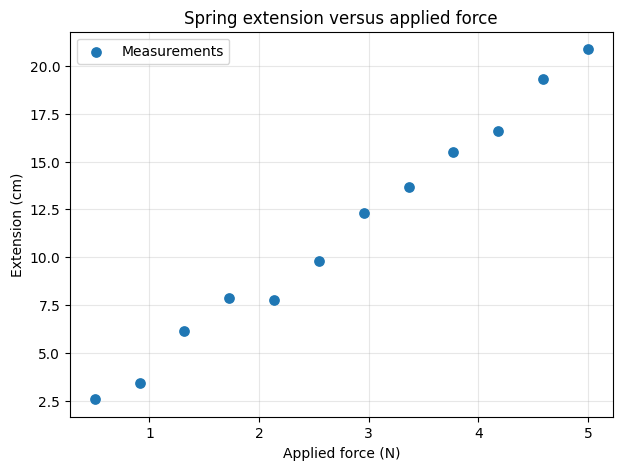

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(force, extension, s=45, zorder=3, label="Measurements")

plt.xlabel("Applied force (N)")
plt.ylabel("Extension (cm)")
plt.title("Spring extension versus applied force")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

The points lie close to a straight line, so a linear model is a reasonable choice here.

Notice that we made this judgement **by looking**, before choosing a model. That ordering is not
a formality; it is what prevents us from fitting a straight line to something curved.

# 4. Fitting a straight line

## 4.1 The model

Our model has two parameters:

$$
\hat{x} = a F + b
$$

where $a$ is the slope in cm/N and $b$ is the intercept in cm.

We want the values of $a$ and $b$ that make the predictions closest to the measurements.

## 4.2 Measuring how wrong a given line is

Let us first write the loss explicitly, as a function we can evaluate for any candidate line.

In [ ]:
def mse(a, b, x_data, y_data):
    """Mean squared error of the line y = a*x + b on the given data."""
    predictions = a * x_data + b
    residuals = y_data - predictions
    return np.mean(residuals ** 2)


# Try three candidate lines, none of them fitted
for a, b in [(3.0, 0.0), (4.0, 0.4), (5.0, 1.0)]:
    print(f"  a = {a:.1f}, b = {b:.1f}   ->   MSE = {mse(a, b, force, extension):.4f}")

  a = 3.0, b = 0.0   ->   MSE = 11.9540
  a = 4.0, b = 0.4   ->   MSE = 0.3104
  a = 5.0, b = 1.0   ->   MSE = 13.8344


Those three numbers are easier to trust once you can see what they correspond to. The figure below
draws the same three candidate lines through the measurements, each labelled with its own loss.

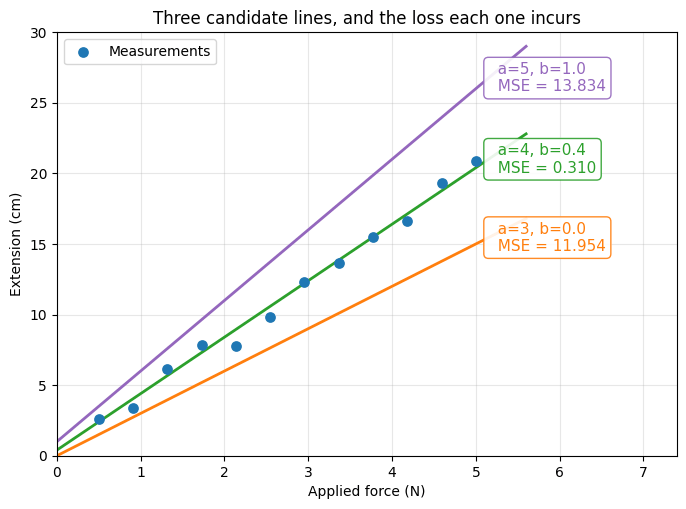

In [ ]:
candidates = [(3.0, 0.0), (4.0, 0.4), (5.0, 1.0)]
colours = ["tab:orange", "tab:green", "tab:purple"]

F_line = np.linspace(0, 5.6, 100)

plt.figure(figsize=(8, 5.5))
plt.scatter(force, extension, s=45, zorder=4, color="tab:blue", label="Measurements")

for (a, b), colour in zip(candidates, colours):
    plt.plot(F_line, a * F_line + b, color=colour, linewidth=2)

    # Put the loss on the line itself, at the right-hand end.
    x_label = 5.15
    plt.text(x_label, a * x_label + b, f"  a={a:.0f}, b={b:.1f}\n  MSE = {mse(a, b, force, extension):.3f}",
             color=colour, fontsize=11, va="center",
             bbox={"facecolor": "white", "edgecolor": colour, "boxstyle": "round,pad=0.3", "alpha": 0.9})

plt.xlabel("Applied force (N)")
plt.ylabel("Extension (cm)")
plt.title("Three candidate lines, and the loss each one incurs")
plt.xlim(0, 7.4)
plt.ylim(0, 30)
plt.grid(alpha=0.3)
plt.legend(loc="upper left")
plt.show()

The picture and the numbers say the same thing. The green line passes through the middle of the
measurements and its loss is about three tenths of a centimetre squared; the other two sit
visibly away from the data, and their losses are roughly forty times larger.

Notice also that the two poor lines have *similar* losses, around 12 and 14, despite one being too
shallow and the other too steep. The loss records how badly a line fits, not in which direction it
is wrong. That is why fitting needs a search over parameters, rather than a single correction.

The middle line, which happens to use the true parameter values, has by far the smallest loss.

This is the whole idea in miniature: the loss ranks candidate models, and fitting means finding
the best-ranked one.

## 4.3 The loss surface

Because we have only two parameters, we can draw the loss as a surface over all candidate
$(a, b)$ pairs and see the minimum directly.

This is a luxury. With a neural network's millions of parameters, no such picture is available,
which is why Class 7 must introduce gradient descent.

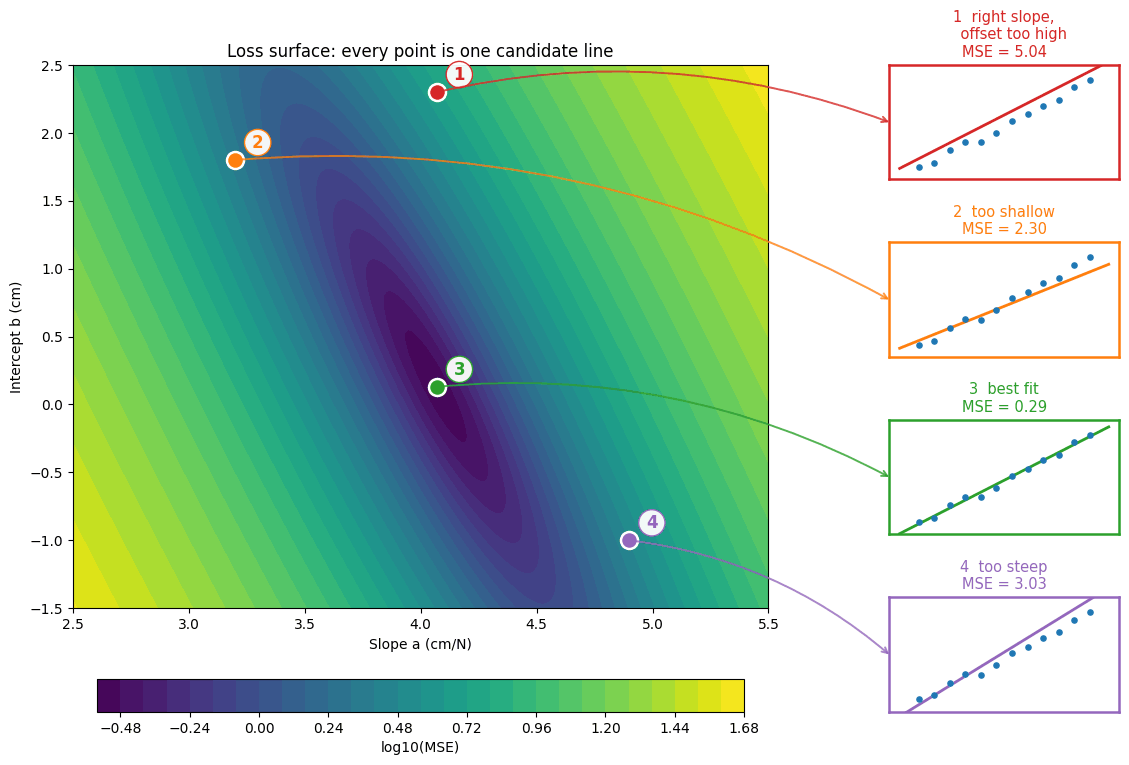

In [ ]:
from matplotlib.patches import ConnectionPatch

a_grid = np.linspace(2.5, 5.5, 200)
b_grid = np.linspace(-1.5, 2.5, 200)
A, B = np.meshgrid(a_grid, b_grid)

loss_surface = np.zeros_like(A)
for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        loss_surface[i, j] = mse(A[i, j], B[i, j], force, extension)

# Four candidate parameter pairs to look at, one of them the best fit.
# Listed top to bottom by intercept, so the connecting arrows never cross.
probes = [
    (4.07,  2.30, "tab:red",    "1  right slope,\n    offset too high"),
    (3.20,  1.80, "tab:orange", "2  too shallow"),
    (4.07,  0.13, "tab:green",  "3  best fit"),
    (4.90, -1.00, "tab:purple", "4  too steep"),
]

fig = plt.figure(figsize=(13.5, 8.4))
gs = fig.add_gridspec(4, 3, width_ratios=[1.25, 1.25, 1.0], wspace=0.45, hspace=0.55)
ax_surf = fig.add_subplot(gs[:, 0:2])

contours = ax_surf.contourf(A, B, np.log10(loss_surface), levels=30, cmap="viridis")
fig.colorbar(contours, ax=ax_surf, orientation="horizontal", pad=0.11,
             label="log10(MSE)", fraction=0.05)
ax_surf.set_xlabel("Slope a (cm/N)")
ax_surf.set_ylabel("Intercept b (cm)")
ax_surf.set_title("Loss surface: every point is one candidate line")

F_line = np.linspace(0, 5.5, 50)

for row, (a, b, colour, label) in enumerate(probes):
    ax_surf.scatter([a], [b], s=150, color=colour, edgecolor="white", linewidth=1.8, zorder=5)
    ax_surf.annotate(label.split()[0], (a, b), textcoords="offset points", xytext=(12, 9),
                     fontsize=12, fontweight="bold", color=colour,
                     bbox={"facecolor": "white", "edgecolor": colour,
                           "boxstyle": "circle,pad=0.25", "alpha": 0.95})

    ax_p = fig.add_subplot(gs[row, 2])
    ax_p.scatter(force, extension, s=14, color="tab:blue", zorder=3)
    ax_p.plot(F_line, a * F_line + b, color=colour, linewidth=2)
    ax_p.set_ylim(0, 24)
    ax_p.set_xticks([]); ax_p.set_yticks([])
    ax_p.set_title(f"{label}\nMSE = {mse(a, b, force, extension):.2f}", fontsize=10.5, color=colour)
    for spine in ax_p.spines.values():
        spine.set_edgecolor(colour); spine.set_linewidth(1.8)

    # tie each panel to the point on the surface it corresponds to
    con = ConnectionPatch(xyA=(a, b), coordsA=ax_surf.transData,
                          xyB=(0, 0.5), coordsB=ax_p.transAxes,
                          arrowstyle="->", linewidth=1.4, color=colour,
                          connectionstyle="arc3,rad=-0.15", alpha=0.8)
    fig.add_artist(con)

plt.show()

Each of the four marked points is one candidate line, and the panel beside it shows what that
line actually looks like against the measurements. Walking downhill on the surface means moving
towards a line that passes through the data.

The surface has a single valley, and its floor is a smooth bowl.

This is a special and very convenient property: for linear regression with squared error, the
loss is a **convex** function of the parameters. Convexity alone rules out local minima to get
trapped in. Here there is exactly one minimum as well, because the two features are not redundant;
if a column were an exact copy of another, the valley floor would be a flat line rather than a point
and the fit would have no unique answer. Class 3 returns to the near-redundant case, which is one of
the reasons for a penalty.

Most models in this course do not have this property. Neural networks certainly do not.

Notice also that the valley is elongated and tilted. Slope and intercept are **correlated**: if we
increase the slope, we can partly compensate by decreasing the intercept. This is why the two
parameters cannot be determined independently of one another.

## 4.4 The least squares solution

For this model the minimum can be found exactly, by setting the derivatives of the loss with
respect to $a$ and $b$ to zero.

The result is the classical least squares solution:

$$
\hat{a} = \frac{\sum_i (F_i - \bar{F})(x_i - \bar{x})}{\sum_i (F_i - \bar{F})^2}
\qquad\qquad
\hat{b} = \bar{x} - \hat{a}\,\bar{F}
$$

Let us compute it directly, so that the formula is not a black box.

In [ ]:
F_mean = force.mean()
x_mean = extension.mean()

a_hat = np.sum((force - F_mean) * (extension - x_mean)) / np.sum((force - F_mean) ** 2)
b_hat = x_mean - a_hat * F_mean

print(f"Fitted slope     a = {a_hat:.4f} cm/N   (true {100/k_true:.4f})")
print(f"Fitted intercept b = {b_hat:.4f} cm     (true {offset_true:.4f})")
print(f"MSE at the fit       {mse(a_hat, b_hat, force, extension):.4f}")

Fitted slope     a = 4.0656 cm/N   (true 4.0000)
Fitted intercept b = 0.1345 cm     (true 0.4000)
MSE at the fit       0.2946


The fitted values are close to the true ones, but not identical.

They should not be identical. The measurements contain random error, so the best line through
*these particular* measurements is not exactly the true line. Repeating the experiment would give
slightly different estimates.

This distinction between the true parameter and our estimate of it runs through all of statistics
and machine learning.

It is worth seeing exactly what quantity was minimised. The vertical grey segments below are the
residuals: the gap between each measurement and the line's prediction at that force. Least squares
chooses the line making the **sum of the squares of these lengths** as small as possible.

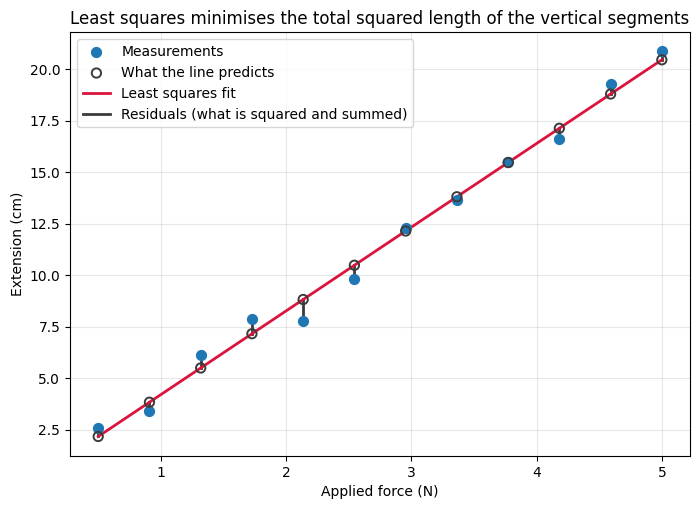

In [ ]:
predicted = a_hat * force + b_hat

plt.figure(figsize=(8, 5.5))

for f, obs, pred in zip(force, extension, predicted):
    plt.plot([f, f], [obs, pred], color="#3b3b3b", linewidth=2.0, zorder=2)

plt.scatter(force, extension, s=50, zorder=4, label="Measurements")
plt.scatter(force, predicted, s=45, facecolors="none", edgecolors="#3b3b3b",
            linewidth=1.4, zorder=5, label="What the line predicts")
plt.plot(force, predicted, color="crimson", linewidth=2, zorder=3, label="Least squares fit")
plt.plot([], [], color="#3b3b3b", linewidth=2.0, label="Residuals (what is squared and summed)")

plt.xlabel("Applied force (N)")
plt.ylabel("Extension (cm)")
plt.title("Least squares minimises the total squared length of the vertical segments")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Two details are worth noticing. The segments are **vertical**, not perpendicular to the line: the
method assumes the error is in the measured extension, not in the applied force. And some segments
point up while others point down — squaring is what stops them cancelling.

# 5. The same fit with NumPy and scikit-learn

In practice we do not implement least squares by hand. Two standard routes are available.

## 5.1 NumPy

`np.polyfit(x, y, deg)` fits a polynomial of the given degree. Degree 1 is a straight line.

It returns the coefficients in order of decreasing power, so for a line the slope comes first.

In [ ]:
coefficients = np.polyfit(force, extension, 1)
print("np.polyfit ->", coefficients)

slope_np, intercept_np = coefficients
print(f"  slope     {slope_np:.4f} cm/N")
print(f"  intercept {intercept_np:.4f} cm")

np.polyfit -> [4.06564802 0.13454178]
  slope     4.0656 cm/N
  intercept 0.1345 cm


## 5.2 scikit-learn

`scikit-learn` is the standard machine learning library for Python, and we will use it throughout
the course. Its interface is worth learning properly now, because every model in the library uses
the same one.

The pattern is always:

```python
model = SomeModel(...)      # 1. create, with any settings
model.fit(X, y)             # 2. fit to training data
predictions = model.predict(X_new)   # 3. predict on new data
```

One detail catches everyone the first time: `X` must be **two-dimensional**, of shape
`(n_samples, n_features)`, even when there is only one feature.

Our `force` array has shape `(12,)`. We reshape it to `(12, 1)`.

In [ ]:
from sklearn.linear_model import LinearRegression

X = force.reshape(-1, 1)     # shape (12, 1): 12 samples, 1 feature
y = extension                # shape (12,)

print("X shape:", X.shape)
print("y shape:", y.shape)

model = LinearRegression()
model.fit(X, y)

print(f"\nslope     {model.coef_[0]:.4f} cm/N")
print(f"intercept {model.intercept_:.4f} cm")

X shape: (12, 1)
y shape: (12,)

slope     4.0656 cm/N
intercept 0.1345 cm


All three routes, the explicit formula, `np.polyfit` and `scikit-learn`, give the same answer.

They are solving the same optimization problem. The difference is only convenience.

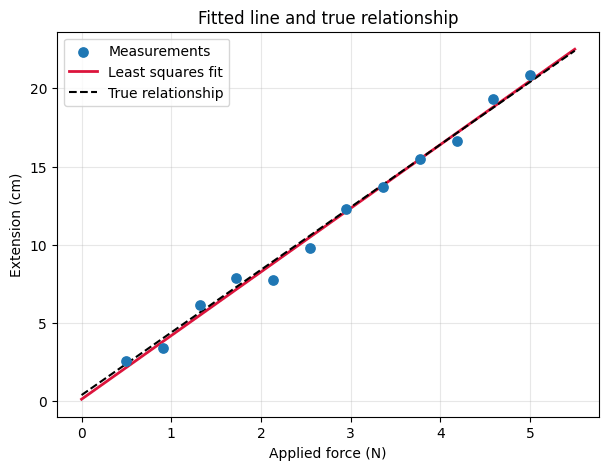

In [ ]:
F_line = np.linspace(0, 5.5, 100)
x_line = model.predict(F_line.reshape(-1, 1))

plt.figure(figsize=(7, 5))
plt.scatter(force, extension, s=45, zorder=3, label="Measurements")
plt.plot(F_line, x_line, color="crimson", linewidth=2, label="Least squares fit")
plt.plot(F_line, (100 / k_true) * F_line + offset_true, "k--",
         linewidth=1.5, label="True relationship")

plt.xlabel("Applied force (N)")
plt.ylabel("Extension (cm)")
plt.title("Fitted line and true relationship")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

<div class="alert alert-success">
<b>Mini-exercise 1 — Fitting a line</b><br>
1. Change the random seed in Section 3.1 and re-run the fit. How much do the fitted slope and intercept change?<br>
2. Increase <code>noise_std</code> from <code>0.6</code> to <code>1.5</code>. What happens to the estimates?<br>
3. Reduce the number of measurements from 12 to 4. What happens?<br>
4. Based on these experiments, what two things make a fitted parameter more reliable?
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 6. Interpreting the fit

A fitted model is not just a prediction machine. In scientific work, the parameters usually mean
something.

## 6.1 Coefficients carry units

Our slope is measured in cm/N, because it converts a force into an extension.

From Hooke's law, the slope equals $100/k$, so we can recover the spring constant:

$$
k = \frac{100}{\hat{a}}
$$

In [ ]:
k_estimated = 100.0 / model.coef_[0]

print(f"Estimated spring constant: {k_estimated:.2f} N/m")
print(f"True spring constant:      {k_true:.2f} N/m")
print(f"Relative error:            {100 * abs(k_estimated - k_true) / k_true:.1f} %")

Estimated spring constant: 24.60 N/m
True spring constant:      25.00 N/m
Relative error:            1.6 %


This is what regression is doing in a great deal of experimental science: it is **parameter
estimation**. The line itself is of no interest. The physical constant extracted from its slope is.

The intercept is also informative. It estimates the ruler's zero offset, a systematic error of the
apparatus. Had we forced the line through the origin, that error would have contaminated the slope
and biased our estimate of $k$.

## 6.2 A warning about interpreting coefficients

Coefficients are interpretable here because we have a physical model telling us what they mean.

Without such a model, interpretation is much more delicate. In Section 8 we will fit a model with
ten features, and there the coefficients will *not* support a simple causal reading.

# 7. Residuals: the most useful diagnostic

## 7.1 What residuals are

The **residual** of observation $i$ is the part the model failed to explain:

$$
r_i = y_i - \hat{y}_i
$$

A single summary number such as the MSE tells us how large the residuals are on average.

Plotting the residuals tells us something more valuable: **whether they have structure**.

## 7.2 Good residuals look like noise

If the model is adequate, the residuals should look like random scatter about zero, with no
visible pattern as the input varies.

> The cell below asks for `residuals.std(ddof=2)`, and the 2 is doing real work. Fitting the line
> used up two degrees of freedom — one for the slope, one for the intercept — so the residuals have
> only $n-2$ independent values left in them. Dividing by $n-2$ rather than $n$ is what makes the
> result an unbiased estimate of the noise **variance**, which is why its square root can be
> compared with `noise_std` on the line below it. This is the same `ddof` argument noted in `01C` §4.5,
> where the choice was between NumPy's and pandas' conventions; here it counts fitted parameters.

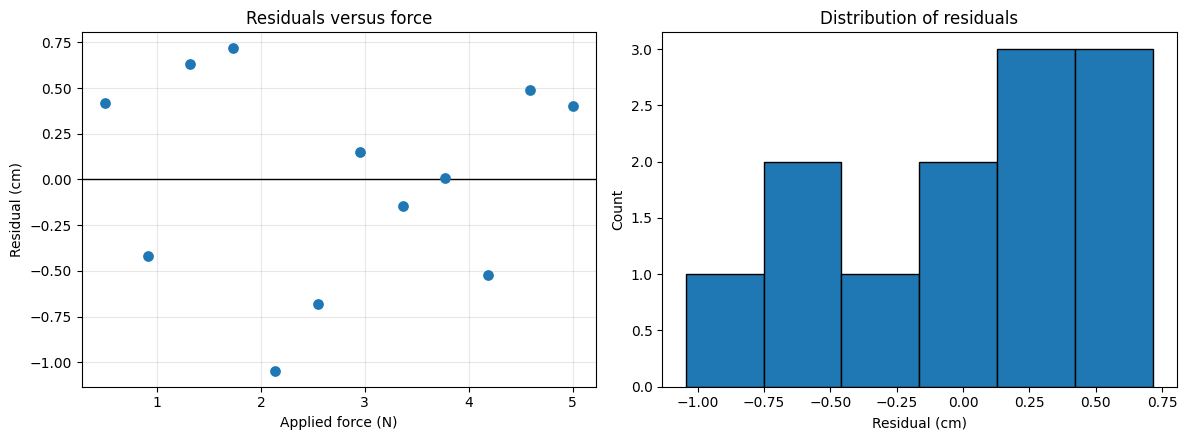

Mean residual:               -5.18e-16 cm
Std of residuals:            0.595 cm
Assumed measurement error:   0.600 cm


In [ ]:
predictions = model.predict(X)
residuals = extension - predictions

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(force, residuals, s=45, zorder=3)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_xlabel("Applied force (N)")
axes[0].set_ylabel("Residual (cm)")
axes[0].set_title("Residuals versus force")
axes[0].grid(alpha=0.3)

axes[1].hist(residuals, bins=6, edgecolor="black")
axes[1].set_xlabel("Residual (cm)")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of residuals")

plt.tight_layout()
plt.show()

print(f"Mean residual:               {residuals.mean():.2e} cm")
print(f"Std of residuals:            {residuals.std(ddof=2):.3f} cm")
print(f"Assumed measurement error:   {noise_std:.3f} cm")

Two observations.

First, the mean residual is essentially zero. This is not a coincidence or a sign of a good fit:
least squares with an intercept **always** produces residuals summing to zero. It tells us nothing.

Second, the spread of the residuals is close to the measurement error we put in. This *is*
informative. It says the model explains the data down to the level of the noise, and there is
nothing systematic left over.

Residual scatter that matches the known instrumental precision is about the best outcome an
experimentalist can hope for.

## 7.3 Bad residuals have structure

Now suppose we stretch the spring beyond its elastic limit, where Hooke's law stops holding and
the response becomes slightly nonlinear.

We will simulate that, fit a straight line anyway, and look at the residuals.

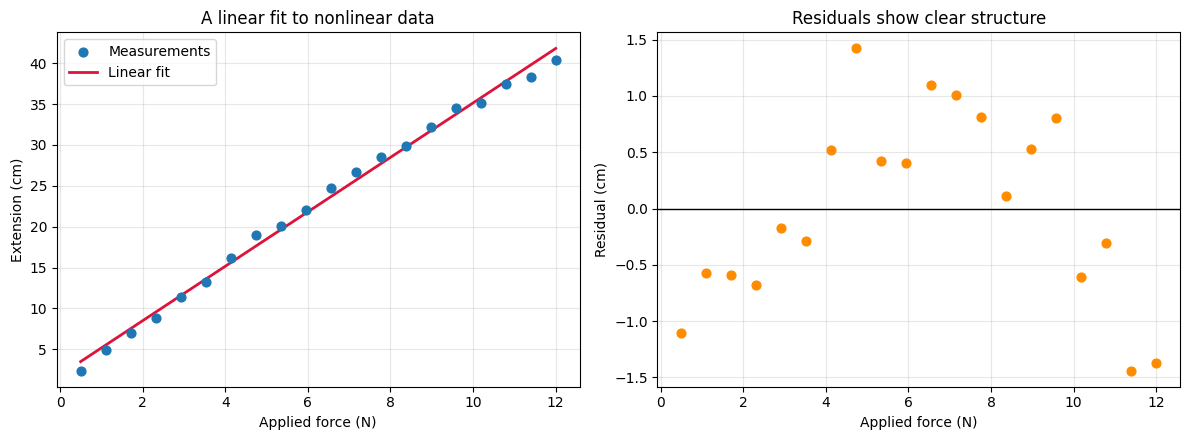

vertical span of the measurements:  38.0 cm
vertical span of the residuals:      2.9 cm


In [ ]:
# Its own generator, so that editing this cell — as mini-exercise 2 asks you to —
# changes only what you edited, and not the noise as well.
rng_wide = np.random.default_rng(7)

force_wide = np.linspace(0.5, 12.0, 20)

# Hooke's law plus a small quadratic stiffening term
extension_nl = ((100.0 / k_true) * force_wide
                - 0.05 * force_wide ** 2
                + offset_true
                + rng_wide.normal(0, noise_std, size=force_wide.shape))

model_nl = LinearRegression().fit(force_wide.reshape(-1, 1), extension_nl)
residuals_nl = extension_nl - model_nl.predict(force_wide.reshape(-1, 1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(force_wide, extension_nl, s=40, zorder=3, label="Measurements")
axes[0].plot(force_wide, model_nl.predict(force_wide.reshape(-1, 1)),
             color="crimson", linewidth=2, label="Linear fit")
axes[0].set_xlabel("Applied force (N)")
axes[0].set_ylabel("Extension (cm)")
axes[0].set_title("A linear fit to nonlinear data")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].scatter(force_wide, residuals_nl, s=40, zorder=3, color="darkorange")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_xlabel("Applied force (N)")
axes[1].set_ylabel("Residual (cm)")
axes[1].set_title("Residuals show clear structure")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"vertical span of the measurements: {extension_nl.max() - extension_nl.min():5.1f} cm")
print(f"vertical span of the residuals:    {residuals_nl.max() - residuals_nl.min():5.1f} cm")

Look at the two panels carefully.

In the left panel the fit looks acceptable. The line passes through the data and nothing screams
that it is wrong.

In the right panel the failure is unmistakable. The residuals form a clean arc: negative at both
ends, positive in the middle. That curve is the part of the physics the straight line could not
capture.

> A pattern in the residuals means the model is missing something real.

Here, the missing thing is the nonlinearity of the spring at large extension, which is a physical
result about the material. The diagnostic is not merely statistical bookkeeping.

### Why the right panel shows more, when it contains no more

This is worth being precise about, because the residuals contain **no information the left panel
does not**. Subtracting the fitted line is reversible: add it back and the measurements return.
Nothing was gained. What changed is what the eye can resolve, and that happens for two reasons.

**The axis is rescaled.** The measurements span about 38 cm, the residuals about 3 — the numbers
printed under the figure. Removing the dominant linear trend magnifies the vertical axis roughly
thirteenfold. The systematic curvature here is about 2.2 cm: six per cent of the range on the
left, where it is invisible, and three quarters of the range on the right, where it is the only
thing to see. 

**The reference becomes horizontal.** Judging whether points curve away from a *sloping* line is
something people do poorly; judging departure from a horizontal one is something they do well.
Removing the trend turns the harder perceptual task into the easier one.

Both of those are about seeing rather than about information, so a sufficiently determined reader
could in principle find the arc in the left panel. The third reason is not:

**With more than one feature there is no left panel.** Extension against force can be drawn because
there is one input. The ten-feature model in section 8 has no such picture — you cannot plot the
data against all ten inputs at once. The next subsection shows the plot that survives into that
case.


### Residuals against fitted values

Both residual plots so far put the residual against **force** — the one input this experiment has.
With ten inputs that choice disappears: there is no single horizontal axis, and ten separate plots
is not a diagnostic, it is a chore.

The plot that generalises puts the residual against the model's own **fitted value** $\hat{y}$.
That is one number per observation whatever the number of features, so the picture stays
two-dimensional for any model at all.

It is worth being careful about which quantity goes on that axis. The natural-sounding choice —
residual against the **observed** target $y$ — is a trap. Because $y = \hat{y} + e$, the residual is
part of the target, and for any least-squares fit with an intercept the two are correlated by
construction: their correlation is $\sqrt{1 - R^2}$. A perfectly correct model still produces a
tilted cloud. Against $\hat{y}$ that same fitting makes the correlation exactly zero, so any
*structure* that does appear there is real — which is what makes this plot trustworthy for the
least-squares models of this class. For a model fitted some other way the orthogonality is only
approximate, and the plot is read more cautiously.

Notice what that formula implies: the artefact is *worst when the model is weakest*, which is
exactly when you are most tempted to go looking for structure. The cell below therefore repeats the
spring experiment with a much coarser ruler. The physics is unchanged and a straight line is still
the correct model — only the measurement error is larger.

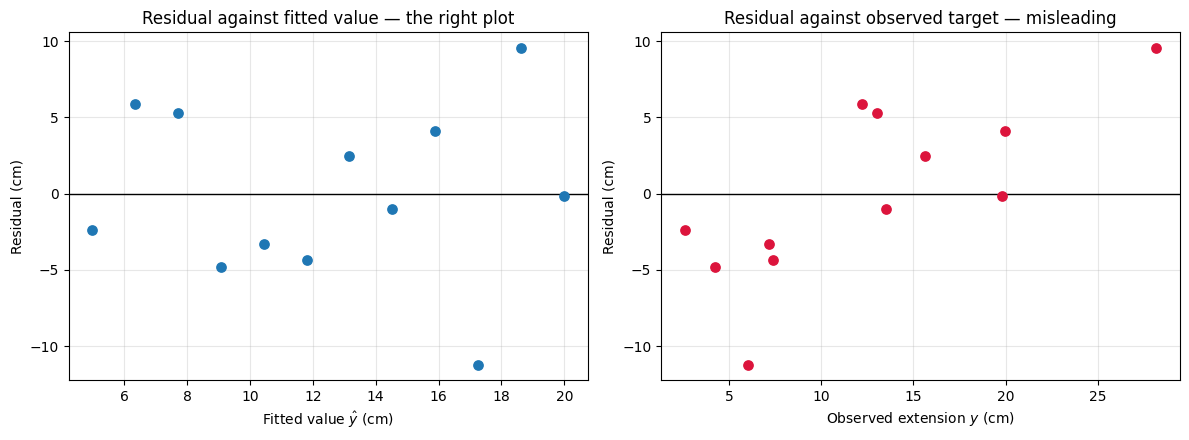

R^2 of this fit:                              0.424
correlation of residual with fitted value:    -0.000
correlation of residual with observed target: +0.759
sqrt(1 - R^2):                                +0.759


In [ ]:
# The same spring and the same physics, measured with a much coarser ruler.
# The straight-line model is still exactly the right model.
rng_coarse = np.random.default_rng(11)          # again, its own, so this cell is re-runnable
coarse_noise = 6.0
extension_coarse = ((100.0 / k_true) * force + offset_true
                   + rng_coarse.normal(0, coarse_noise, size=force.shape))

model_coarse = LinearRegression().fit(X, extension_coarse)
fitted_coarse = model_coarse.predict(X)
residuals_coarse = extension_coarse - fitted_coarse

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(fitted_coarse, residuals_coarse, s=45, zorder=3)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_xlabel("Fitted value $\\hat{y}$ (cm)")
axes[0].set_ylabel("Residual (cm)")
axes[0].set_title("Residual against fitted value — the right plot")
axes[0].grid(alpha=0.3)

axes[1].scatter(extension_coarse, residuals_coarse, s=45, zorder=3, color="crimson")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_xlabel("Observed extension $y$ (cm)")
axes[1].set_ylabel("Residual (cm)")
axes[1].set_title("Residual against observed target — misleading")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

r_squared = model_coarse.score(X, extension_coarse)
print(f"R^2 of this fit:                              {r_squared:.3f}")
print(f"correlation of residual with fitted value:    {np.corrcoef(residuals_coarse, fitted_coarse)[0, 1]:+.3f}")
print(f"correlation of residual with observed target: {np.corrcoef(residuals_coarse, extension_coarse)[0, 1]:+.3f}")
print(f"sqrt(1 - R^2):                                {np.sqrt(1 - r_squared):+.3f}")

The left panel is the structureless band we want, and its correlation is zero to numerical
precision — forced by the fitting, not evidence of a good model.

The right panel slopes clearly upward, and the printed correlation matches $\sqrt{1 - R^2}$
exactly. That slope is an artefact of plotting a quantity against something it is part of. Nothing
whatever is wrong with this model: the same tilt appears for any model, and grows as $R^2$ falls.
On the precise twelve-point spring of section 7.2, where $R^2 \approx 0.99$, the tilt is only
0.09 and invisible — which is why the trap is easy to miss until it matters.

So: **residual against fitted value** is the diagnostic to reach for by default. Residual against an
individual feature, as in the two plots above, stays useful when there are few features and you
want to know *which* input the model handles badly — it is how the spring's nonlinearity was
located. Residual against the observed target is the one to avoid.

<div class="alert alert-success">
<b>Mini-exercise 2 — Reading residuals</b><br>
1. Change the coefficient of the quadratic term from <code>-0.05</code> to <code>-0.005</code>. Is the structure still visible in the residual plot? Is it visible in the fitted-line plot?<br>
2. Set the quadratic coefficient to <code>0.0</code>. What do the residuals look like now?<br>
3. Restrict the force range to <code>np.linspace(0.5, 4.0, 20)</code> with the original <code>-0.05</code> term. Can you still detect the nonlinearity?<br>
4. What does part 3 suggest about the range over which an experiment should be conducted?
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

## 7.4 The coefficient of determination, $R^2$

Residual plots are the most informative diagnostic, but they are pictures, and you often need a
single number: to compare two models, to tune a model automatically, or to report a result. For
regression the most widely used one is the **coefficient of determination**, written $R^2$.

It compares the model against the laziest possible predictor: always guessing the mean of the
target, ignoring the input entirely.

$$
R^2 \;=\; 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}
$$

The numerator is the squared error the model leaves behind; the denominator is the squared error
that guessing $\bar{y}$ would leave. So:

- $R^2 = 1$ — the model reproduces the data exactly;
- $R^2 = 0$ — the model is no better than guessing the mean;
- $R^2 < 0$ — the model is *worse* than guessing the mean, which is possible.

**It is the MSE, rescaled.** Divide the top and the bottom of the fraction by $n$. The top becomes
the mean squared error of section 4.2, and the bottom becomes the variance of the target:

$$
R^2 \;=\; 1 - \frac{\mathrm{MSE}}{\operatorname{Var}(y)} .
$$

On a given dataset $\operatorname{Var}(y)$ is a fixed number, so $R^2$ is the MSE turned upside down
and rescaled: whichever model has the lower MSE has the higher $R^2$.

Because it compares *squared* errors, $1 - R^2$ is the fraction of the **variance** left unexplained,
not the fraction of the error. To get back to the target's own units take the square root:
$\sqrt{1 - R^2}$ is the typical error that remains, as a fraction of the typical error of guessing
the mean. An $R^2$ of 0.75 sounds like three quarters of the job done; in the target's units it
leaves errors half as large as knowing nothing at all. It contains no information
that the MSE does not. In particular it cannot tell you whether the model has the right *shape*, any
more than the MSE can — section 7.3's residual plot is how you find that out.

**Why it is used anyway.** The rescaling buys two conveniences, and a third comes from habit.

- **It has no units.** Unlike the MSE, it does not change if you measure extension in centimetres
  rather than metres, so one scale — up to 1 — covers every regression problem.
- **It has a baseline built in.** "0" always means "no better than the mean", so a value on its own
  already says whether the model has learned anything at all.
- **It is `scikit-learn`'s default.** Every regressor's `.score()` method returns $R^2$, and so
  does any tool that calls it — cross-validation and hyperparameter search included — unless you
  ask for something else. You will meet it constantly whether you choose it or not.

**Its catch comes from the same rescaling.** $\operatorname{Var}(y)$ belongs to the *dataset*, not
to the model. Measure the same spring over a wider range of forces and the extensions vary more, so
the same measurement errors give a higher $R^2$. **Compare $R^2$ only between models fitted to the
same data**; `03A` §2.3 shows how far apart two experiments on one spring can land. And, like the
MSE, when it is computed on the data the model was fitted to it can only improve as features are
added — section 8.3 runs into this.

# 8. Multiple linear regression

## 8.1 More than one feature

Real scientific problems rarely have a single input. The model generalises directly:

$$
\hat{y} = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \cdots + \theta_p x_p
$$

or compactly, $\hat{y} = \theta_0 + \boldsymbol{\theta}^\top \mathbf{x}$.

That is the prediction for one sample. A dataset has many, and the natural way to handle them is to
stack the samples as the rows of a matrix $X$ — one row per sample, one column per feature, the
layout of `01C` §2.2. Then all $n$ predictions come out of a single matrix–vector product, with
$\theta_0$ added to every one of them:

$$
\hat{\mathbf{y}} \;=\; \theta_0 + X\boldsymbol{\theta} .
$$

The picture shows the shapes involved.

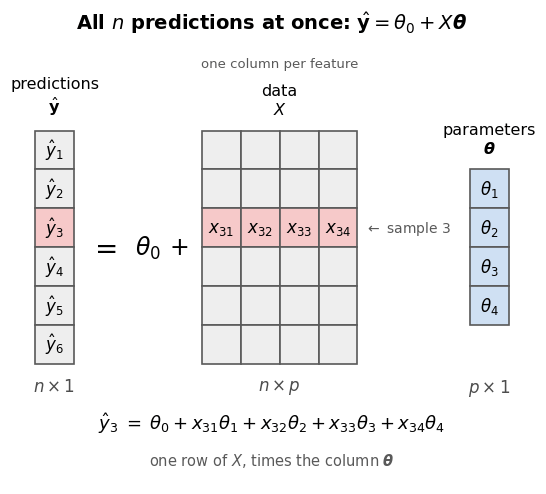

In [ ]:
# Figure: the shapes in y_hat = theta_0 + X theta.  Drawing code only — nothing here needs following.
from matplotlib.patches import Rectangle

n_rows, n_cols, row = 6, 4, 2                  # six samples, four features, row 3 picked out
PICKED, THETA, PLAIN = "#f6c9c9", "#cfe0f3", "#eeeeee"

def cell(ax, x, y, colour, label=""):
    ax.add_patch(Rectangle((x, y), 1, 1, facecolor=colour, edgecolor="0.35", linewidth=1.2))
    if label:
        ax.text(x + 0.5, y + 0.5, label, ha="center", va="center", fontsize=12)

fig, ax = plt.subplots(figsize=(11.5, 5.8))
top = n_rows                                   # rows are drawn downwards from here
x_hat, x_X = 0.0, 4.3
x_theta = x_X + n_cols + 2.9

for r in range(n_rows):                        # predictions
    cell(ax, x_hat, top - 1 - r, PICKED if r == row else PLAIN, rf"$\hat{{y}}_{r + 1}$")
ax.text(1.75, top / 2, "$=$", ha="center", va="center", fontsize=20)
ax.text(x_X - 0.35, top / 2, r"$\theta_0\,+$", ha="right", va="center", fontsize=17)

for r in range(n_rows):                        # the data matrix
    for j in range(n_cols):
        cell(ax, x_X + j, top - 1 - r, PICKED if r == row else PLAIN,
             rf"$x_{{{r + 1}{j + 1}}}$" if r == row else "")

theta_top = top / 2 + n_cols / 2               # parameters, centred on the data
for j in range(n_cols):
    cell(ax, x_theta, theta_top - 1 - j, THETA, rf"$\theta_{j + 1}$")

for x0, width, name, shape in [(x_hat, 1, "predictions\n" + r"$\hat{\mathbf{y}}$", r"$n \times 1$"),
                               (x_X, n_cols, "data\n" + r"$X$", r"$n \times p$"),
                               (x_theta, 1, "parameters\n" + r"$\boldsymbol{\theta}$", r"$p \times 1$")]:
    ax.text(x0 + width / 2, top + 0.35 if name.startswith(("pred", "data")) else theta_top + 0.35,
            name, ha="center", va="bottom", fontsize=11.5)
    ax.text(x0 + width / 2, -0.35, shape, ha="center", va="top", fontsize=12, color="0.3")

ax.text(x_X + n_cols + 0.2, top - 1 - row + 0.5, r"$\leftarrow$ sample 3", ha="left",
        va="center", fontsize=10, color="0.35")
ax.text(x_X + n_cols / 2, top + 1.55, "one column per feature", ha="center", va="bottom",
        fontsize=9.5, color="0.35")

ax.text((x_hat + x_theta + 1) / 2, -1.2,
        r"$\hat{y}_3 \;=\; \theta_0 + x_{31}\theta_1 + x_{32}\theta_2 + x_{33}\theta_3 + x_{34}\theta_4$",
        ha="center", va="top", fontsize=13)
ax.text((x_hat + x_theta + 1) / 2, -2.25, r"one row of $X$, times the column $\boldsymbol{\theta}$",
        ha="center", va="top", fontsize=10.5, color="0.35")

ax.set_xlim(-0.6, x_theta + 1.6)
ax.set_ylim(-3.1, top + 2.4)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title(r"All $n$ predictions at once: $\hat{\mathbf{y}} = \theta_0 + X\boldsymbol{\theta}$",
             fontsize=14, fontweight="bold")
plt.show()

Each row of $X$, multiplied by the column $\boldsymbol{\theta}$, is exactly the one-sample formula
above — the highlighted row is sample 3. In NumPy the whole thing is one line, `theta_0 + X @ theta`,
using the `@` of `01B` §6.1, and it is what `model.predict(X)` computes for a linear model.

The geometry changes, a line becomes a plane and then a hyperplane, but nothing conceptual does.
The loss is still squared error, the solution is still least squares, and `scikit-learn` does not
even need a different class.

The only change in code is that `X` now has more than one column.

With one feature the model is a line in a plane. With two, it is a **plane** in a
three-dimensional space, with the target on the vertical axis. The picture below makes the claim
concrete before we return to real data.

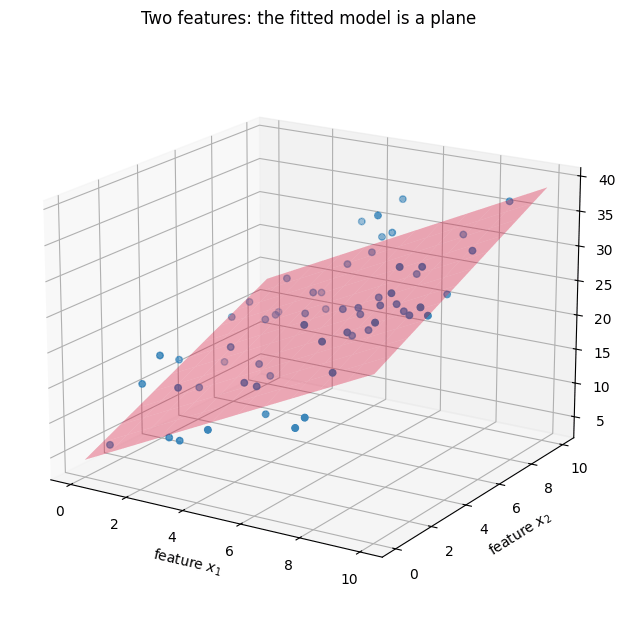

In [ ]:
from mpl_toolkits.mplot3d import Axes3D    # noqa: F401  (registers the 3d projection)

rng_demo = np.random.default_rng(3)
n_demo = 60
x1 = rng_demo.uniform(0, 10, n_demo)
x2 = rng_demo.uniform(0, 10, n_demo)
y_demo = 2.0 * x1 + 1.2 * x2 + 5.0 + rng_demo.normal(0, 4.0, n_demo)

model_3d = LinearRegression().fit(np.column_stack([x1, x2]), y_demo)

grid_1, grid_2 = np.meshgrid(np.linspace(0, 10, 12), np.linspace(0, 10, 12))
grid_y = (model_3d.intercept_
          + model_3d.coef_[0] * grid_1
          + model_3d.coef_[1] * grid_2)

fig = plt.figure(figsize=(9, 6.5))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(grid_1, grid_2, grid_y, alpha=0.35, color="crimson", edgecolor="none")
ax.scatter(x1, x2, y_demo, s=22, color="tab:blue", depthshade=True)

ax.set_xlabel("feature $x_1$")
ax.set_ylabel("feature $x_2$")
ax.set_zlabel("target $y$")
ax.set_title("Two features: the fitted model is a plane")
ax.view_init(elev=18, azim=-58)
plt.tight_layout()
plt.show()

Beyond two features the picture stops being drawable, but nothing else changes: with $p$ features
the model is a flat $p$-dimensional surface in a $(p+1)$-dimensional space, and least squares
still chooses the one closest to the data in the vertical direction.

## 8.2 A real dataset

We use the diabetes dataset bundled with `scikit-learn`. It contains ten physiological
measurements for 442 patients, and the target is a quantitative measure of disease progression one
year later.

The features have already been standardised by the dataset's authors, so each has mean zero.

In [ ]:
import pandas as pd
from sklearn.datasets import load_diabetes

diabetes = load_diabetes(as_frame=True)
data = diabetes.frame

print("Shape:", data.shape)
print("\nColumns:", list(data.columns))
data.head()

Shape: (442, 11)

Columns: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'target']


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


Following the habit from `01D`, we look before we model.

count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64

typical error of predicting the mean for everyone: 77.0


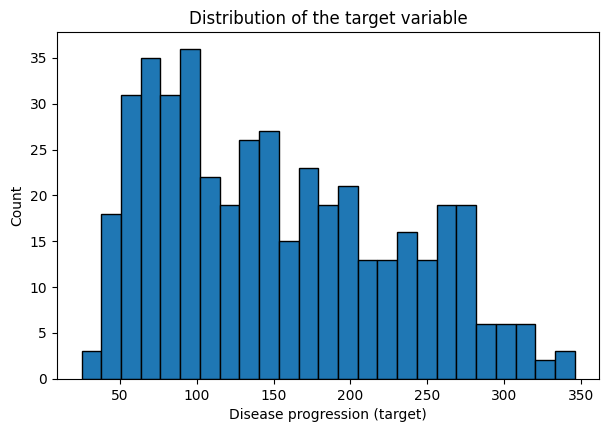

In [ ]:
feature_names = [c for c in data.columns if c != "target"]

X_all = data[feature_names]
y_all = data["target"]

print(y_all.describe())

# The laziest possible prediction: the mean, for every patient. Its typical error is the
# yardstick every model below has to beat.
rmse_of_mean = np.sqrt(np.mean((y_all - y_all.mean()) ** 2))
print(f"\ntypical error of predicting the mean for everyone: {rmse_of_mean:.1f}")

plt.figure(figsize=(7, 4.5))
plt.hist(y_all, bins=25, edgecolor="black")
plt.xlabel("Disease progression (target)")
plt.ylabel("Count")
plt.title("Distribution of the target variable")
plt.show()

What the histogram says, before any model has been fitted:

- **Nothing needs cleaning.** All 442 values are present and positive, from 25 to 346, with no
  impossible values and no isolated point far from the rest. That is the check `01D` taught, and it
  is worth saying out loud when it comes back clean.
- **It sets the yardstick for every error that follows.** Predicting the mean for every patient
  leaves a typical error of 77, printed above. That is the laziest possible predictor of section
  7.4, and $77^2$ is exactly the denominator of $R^2$. A model is only worth having if it does
  clearly better than 77, so hold every error figure in this section against that number.
- **It is skewed to the right.** The values pile up between 50 and 100 and thin out in a long tail
  towards 350, which is why the mean (152) lies above the median (140.5). Squared error weights that tail
  heavily, because the largest errors can come from the few high-progression patients. And a
  positive quantity bunched at low values often has errors that grow with the value — section 8.3
  finds exactly that in the residuals.
- **It has one hump.** Two peaks would hint at two different groups of patients mixed together
  (`01D` §4.5). There is no sign of that here.

## 8.3 Fitting one feature, then all ten

Let us first fit body mass index alone, then all ten features together, and compare.

We use $R^2$, defined in section 7.4, to summarise fit quality — remembering what it cannot tell
us.

In [ ]:
from sklearn.metrics import r2_score

# --- One feature ---
model_bmi = LinearRegression().fit(data[["bmi"]], y_all)
r2_bmi = r2_score(y_all, model_bmi.predict(data[["bmi"]]))

# --- All ten features ---
model_all = LinearRegression().fit(X_all, y_all)
r2_all = r2_score(y_all, model_all.predict(X_all))

print(f"R2 using bmi only:        {r2_bmi:.3f}")
print(f"R2 using all 10 features: {r2_all:.3f}")

# Section 7.4 said R2 is the mean squared error rescaled; the square root of the MSE brings it
# back into the target's own units, where it can be compared with the 77 of section 8.2.
mse_all = np.mean((y_all - model_all.predict(X_all)) ** 2)
print(f"\n1 - MSE / Var(y):         {1 - mse_all / y_all.var(ddof=0):.3f}")
print(f"typical error, sqrt(MSE): {np.sqrt(mse_all):.1f}"
      f"    against {y_all.std(ddof=0):.1f} for predicting the mean")

R2 using bmi only:        0.344
R2 using all 10 features: 0.518

1 - MSE / Var(y):         0.518
typical error, sqrt(MSE): 53.5    against 77.0 for predicting the mean


Adding the other nine features raised $R^2$ from **0.34 to 0.52**: from about a third of the
variance in disease progression accounted for, to about a half.

One caution, which `02C` takes up properly. Both numbers were computed **on the same data the models
were fitted to**, and a number like that can never fall when a feature is added — the fit can always
set the new coefficient to zero and do exactly as well as before. So the rise shows that ten
features describe *these* 442 patients better. Whether they would predict *new* patients better is
a different question, and this notebook does not yet have the tools to answer it.

And even at 0.52, half of the **variance** is left unexplained — and variance is measured in squared
units. In the target's own units the picture is less flattering: $\sqrt{1 - 0.52} \approx 0.69$, so
the typical error falls only from the 77.0 of predicting the mean to 53.5, a reduction of about
30%, not half. $R^2$ always sounds better than the error it describes. And 53.5 is still large when
the middle half of the patients fall between 87 and 212.
This is not a model that would tell an individual patient much about their own prognosis.

Section 7.3 promised that residuals against fitted values remain drawable however many features
there are. This is that case: ten inputs, so no scatter plot of the data exists, and the
diagnostic still works.


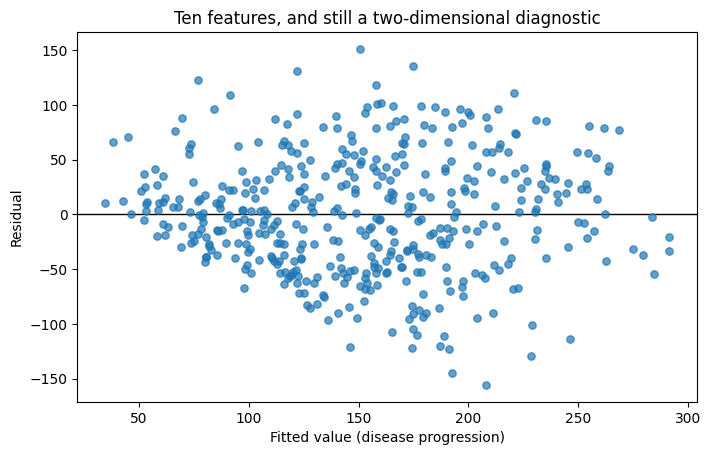

correlation of residual with fitted value: -0.000

   fitted    35 to   111:  residual sd  34.7
   fitted   111 to   153:  residual sd  56.3
   fitted   153 to   191:  residual sd  61.4
   fitted   191 to   291:  residual sd  57.3


In [ ]:
residuals_all = y_all - model_all.predict(X_all)

plt.figure(figsize=(8, 4.8))
plt.scatter(model_all.predict(X_all), residuals_all, s=28, alpha=0.7, zorder=3)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Fitted value (disease progression)")
plt.ylabel("Residual")
plt.title("Ten features, and still a two-dimensional diagnostic")
plt.show()

fitted_all = model_all.predict(X_all)
print(f"correlation of residual with fitted value: "
      f"{np.corrcoef(residuals_all, fitted_all)[0, 1]:+.3f}\n")

# Is the spread of the residuals constant across the range?
edges = np.quantile(fitted_all, [0, 0.25, 0.5, 0.75, 1.0])
for low, high in zip(edges[:-1], edges[1:]):
    inside = (fitted_all >= low) & (fitted_all <= high)
    print(f"   fitted {low:5.0f} to {high:5.0f}:  residual sd {residuals_all[inside].std():5.1f}")


The band is roughly flat, so nothing systematic is left that a linear model could pick up. But the
spread is not constant: for the quarter of patients the model predicts to be least ill the
residuals scatter by about 35, against roughly 55 to 60 for everyone else. The model is
substantially more precise at the low end of the range than elsewhere.

That is worth knowing before quoting a single error figure for the whole model, and no number
reported so far would have revealed it.

The scatter for the single strongest feature shows where the ceiling on $R^2$ comes from.

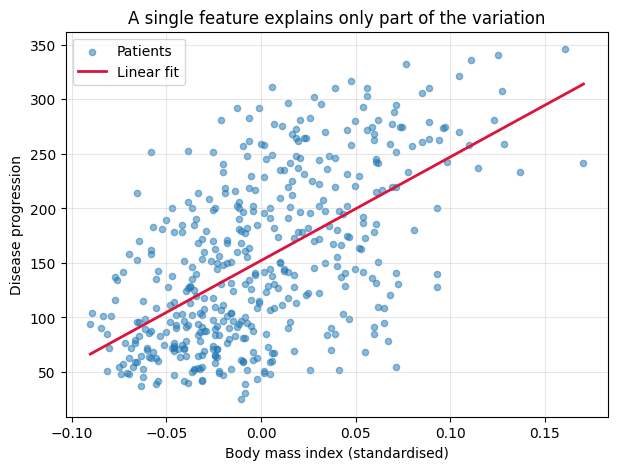

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(data["bmi"], y_all, s=20, alpha=0.5, label="Patients")

# Build the prediction inputs as a DataFrame with the same column name used for fitting.
# Passing a bare array here works, but scikit-learn warns about the missing feature name.
bmi_line = pd.DataFrame({"bmi": np.linspace(data["bmi"].min(), data["bmi"].max(), 100)})

plt.plot(bmi_line["bmi"], model_bmi.predict(bmi_line), color="crimson",
         linewidth=2, label="Linear fit")

plt.xlabel("Body mass index (standardised)")
plt.ylabel("Disease progression")
plt.title("A single feature explains only part of the variation")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Compare this scatter with the spring measurements in Section 3.2.

The spring data lay almost exactly on a line. Here the points form a broad cloud with a visible
upward trend. The relationship is real but weak, and no straight line will predict any individual
patient well.

This is much more typical of scientific and biomedical data than the spring example is.

Which leaves an obvious question. If nine additional measurements together buy us only about
eighteen points of $R^2$, which of them are carrying that improvement, and which are simply along
for the ride?

A linear model looks as though it answers this directly. Every feature has its own coefficient,
and a larger coefficient ought to mean a larger influence on the prediction. That reading is
tempting, widely used, and — as the next section shows — unsafe.

## 8.4 Reading the coefficients

The features were standardised by the dataset's authors, so they are all on the same scale. That
removes the most obvious objection to comparing coefficients directly: a large coefficient can no
longer just mean "this variable happens to be measured in small units".

So let us look.

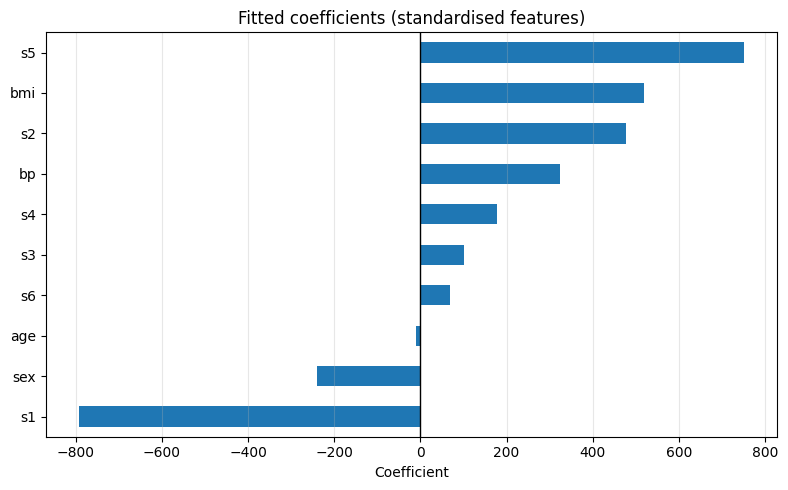

s1    -792.2
sex   -239.8
age    -10.0
s6      67.6
s3     101.0
s4     177.1
bp     324.4
s2     476.7
bmi    519.8
s5     751.3
dtype: float64


In [ ]:
coefficients = pd.Series(model_all.coef_, index=feature_names).sort_values()

plt.figure(figsize=(8, 5))
coefficients.plot(kind="barh")
plt.xlabel("Coefficient")
plt.title("Fitted coefficients (standardised features)")
plt.axvline(0, color="black", linewidth=1)
plt.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

print(coefficients.round(1))

This looks like the answer to the question we just asked. It is not.

Several of these features are strongly correlated with one another. The pair `s1` and `s2` has a
correlation of about 0.90, and there are several other pairs above 0.6.

When features are correlated, the fit can distribute influence between them almost arbitrarily,
and individual coefficients become unstable: a small change in the data can swing a coefficient
from large positive to large negative.

Look at `s1` and `s2` in the chart. They are the most strongly correlated pair in the dataset, and
they carry large coefficients of **opposite sign**, roughly -790 and +480. The two features
move together almost in lockstep, so the model can add a large amount of one and subtract a large
amount of the other with little net effect on its predictions.

That is a signature of correlated features, not a discovery about physiology. Neither coefficient
should be read as "the effect of `s1`".

This is one motivation for the regularization methods in Class 3, and it is a specific instance of
the more general warning from `01D`:

> A fitted relationship is not a causal one.

<div class="alert alert-success">
<b>Mini-exercise 3 — Multiple regression</b><br>
1. Fit a linear regression using only <code>bmi</code> and <code>s5</code>. What <code>R2</code> do you obtain?<br>
2. Compute the correlation matrix of the ten features, using the method from <code>01D</code>. Which pairs are most strongly correlated?<br>
3. Fit the model on only the first 200 patients, then on only the last 200. Compare the coefficient for <code>s1</code> between the two fits.<br>
4. What does the comparison in part 3 tell you about how much to trust an individual coefficient?
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 9. Why squared error? Maximum likelihood, and leverage

Minimising the sum of squares can look arbitrary. Why not the sum of absolute errors?

There is a principled answer, and it connects regression to probability. This connection reappears
throughout the course, so it is worth seeing once properly.

Suppose the measurements are generated by a true relationship plus independent Gaussian noise:

$$
y_i = f_{\boldsymbol{\theta}}(\mathbf{x}_i) + \varepsilon_i,
\qquad \varepsilon_i \sim \mathcal{N}(0, \sigma^2)
$$

Then the probability of observing $y_i$ given the parameters is

$$
p(y_i \mid \mathbf{x}_i, \boldsymbol{\theta}) =
\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\!\left(-\frac{(y_i - f_{\boldsymbol{\theta}}(\mathbf{x}_i))^2}{2\sigma^2}\right)
$$

Because the measurements are independent, the **likelihood** of the whole dataset is the product
of these terms. Taking a logarithm turns the product into a sum:

$$
\log p(\mathbf{y} \mid \mathbf{X}, \boldsymbol{\theta}) =
-\frac{1}{2\sigma^2} \sum_{i=1}^{n} \bigl(y_i - f_{\boldsymbol{\theta}}(\mathbf{x}_i)\bigr)^2
\;-\; \frac{n}{2}\log(2\pi\sigma^2)
$$

The second term does not depend on $\boldsymbol{\theta}$. So maximising the log-likelihood over
$\boldsymbol{\theta}$ is exactly minimising

$$
\sum_{i=1}^{n} \bigl(y_i - f_{\boldsymbol{\theta}}(\mathbf{x}_i)\bigr)^2
$$

which is the least squares criterion.

**Least squares is maximum likelihood estimation under Gaussian noise.**

Three consequences are worth stating.

First, the choice of loss encodes an assumption about the noise. It is not a neutral technical
detail.

Second, if the noise is *not* Gaussian, squared error may be a poor choice. Heavy-tailed noise, or
data containing outliers, corresponds to a different distribution and calls for a different loss.
Minimising absolute error is the maximum likelihood solution under Laplace-distributed noise, and
it is far less sensitive to outliers.

Third, this same argument, applied to a categorical target instead of a continuous one, produces
the cross-entropy loss used for classification. That is the subject of notebook `02B`.

The figure below is the same statement drawn. At each force, the model predicts one extension, and
the assumption is that the actual reading is drawn from a bell curve centred on that prediction.
Maximising the likelihood means choosing the line under which the readings we actually got are
the least surprising.

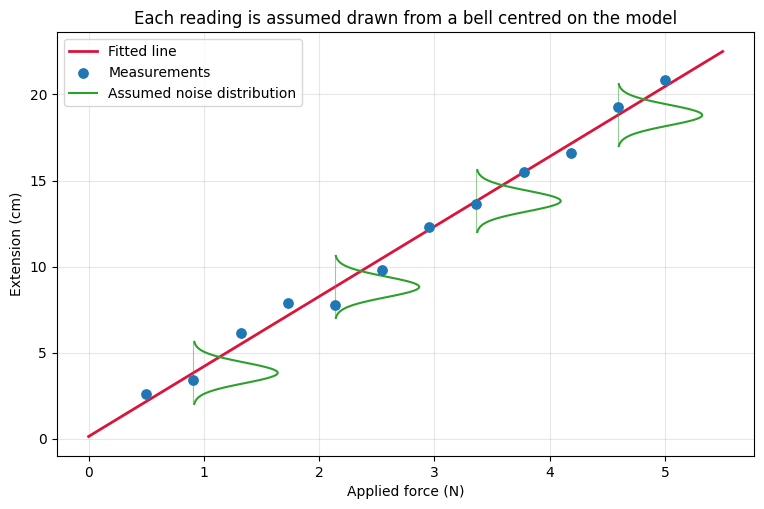

In [ ]:
from scipy.stats import norm

plt.figure(figsize=(9, 5.5))

F_line = np.linspace(0, 5.5, 100)
plt.plot(F_line, a_hat * F_line + b_hat, color="crimson", linewidth=2, label="Fitted line")

# a bell curve, on its side, at four of the measured forces
for idx in [1, 4, 7, 10]:
    f = force[idx]
    centre = a_hat * f + b_hat
    span = np.linspace(centre - 3*noise_std, centre + 3*noise_std, 100)
    density = norm.pdf(span, centre, noise_std)
    plt.plot(f + density * 1.1, span, color="tab:green", linewidth=1.5)
    plt.plot([f, f], [span[0], span[-1]], color="tab:green", linewidth=0.8, alpha=0.5)

plt.scatter(force, extension, s=45, zorder=4, label="Measurements")
plt.plot([], [], color="tab:green", linewidth=1.5, label="Assumed noise distribution")

plt.xlabel("Applied force (N)")
plt.ylabel("Extension (cm)")
plt.title("Each reading is assumed drawn from a bell centred on the model")
plt.grid(alpha=0.3)
plt.legend(loc="upper left")
plt.show()

The choice of loss follows from the shape of that bell. Squared error comes from a Gaussian;
absolute error comes from a heavier-tailed distribution. The difference is visible directly in how
the two losses grow.

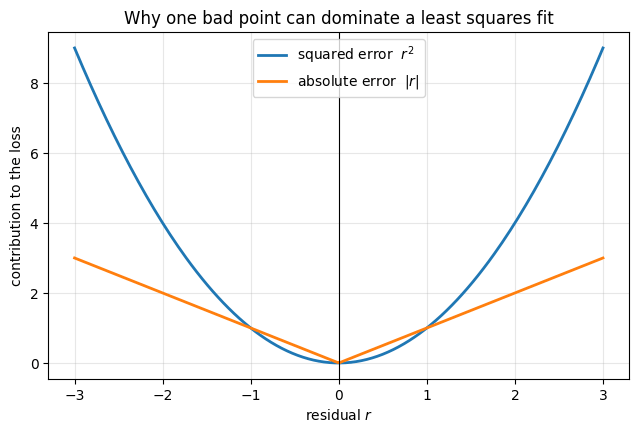

In [ ]:
r = np.linspace(-3, 3, 200)

plt.figure(figsize=(7.5, 4.5))
plt.plot(r, r**2, linewidth=2, label="squared error  $r^2$")
plt.plot(r, np.abs(r), linewidth=2, label="absolute error  $|r|$")

plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("residual $r$")
plt.ylabel("contribution to the loss")
plt.title("Why one bad point can dominate a least squares fit")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

At a residual of 1 the two agree. At a residual of 3 the squared error contributes nine, against
three for the absolute error. A single badly misread value therefore counts for far more under
squared error, which is exactly what the next cell demonstrates.

The sensitivity to outliers is easy to demonstrate. We corrupt a single measurement by 3 cm, as if
one ruler reading had been badly misread, and refit.

We do this twice: once corrupting a point in the **middle** of the force range, and once
corrupting a point at the **end**. The difference between the two is instructive.

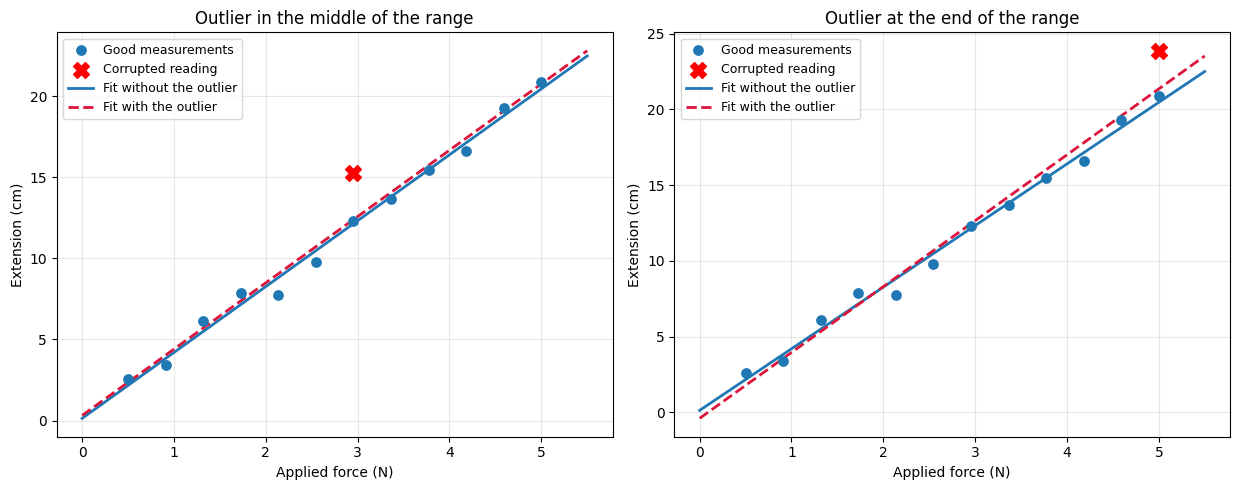

True spring constant:            25.00 N/m
Clean data:                      24.60 N/m
Outlier in the middle:           24.44 N/m
Outlier at the end:              23.00 N/m


In [ ]:
model_clean = LinearRegression().fit(X, extension)

# Corrupt a middle point, then an end point
extension_mid = extension.copy()
extension_mid[6] += 3.0

extension_end = extension.copy()
extension_end[11] += 3.0

model_mid = LinearRegression().fit(X, extension_mid)
model_end = LinearRegression().fit(X, extension_end)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5))

for ax, corrupted, model_c, idx, title in [
    (axes[0], extension_mid, model_mid, 6, "Outlier in the middle of the range"),
    (axes[1], extension_end, model_end, 11, "Outlier at the end of the range"),
]:
    ax.scatter(force, extension, s=45, zorder=3, label="Good measurements")
    ax.scatter(force[idx], corrupted[idx], s=130, color="red",
               marker="X", zorder=4, label="Corrupted reading")
    ax.plot(F_line, model_clean.predict(F_line.reshape(-1, 1)),
            linewidth=2, label="Fit without the outlier")
    ax.plot(F_line, model_c.predict(F_line.reshape(-1, 1)),
            linewidth=2, linestyle="--", color="crimson", label="Fit with the outlier")
    ax.set_xlabel("Applied force (N)")
    ax.set_ylabel("Extension (cm)")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"True spring constant:            {k_true:.2f} N/m")
print(f"Clean data:                      {100 / model_clean.coef_[0]:.2f} N/m")
print(f"Outlier in the middle:           {100 / model_mid.coef_[0]:.2f} N/m")
print(f"Outlier at the end:              {100 / model_end.coef_[0]:.2f} N/m")

The two panels behave very differently, and the printed numbers make it precise.

The **middle** outlier barely changes the estimated spring constant, moving it by well under one
percent. The fitted line shifts upwards a little, but its slope is almost untouched: the corrupted
point pulls the line up without any reason to tilt it.

The **end** outlier changes the slope substantially, shifting the estimated spring constant by
several percent. A point far from the mean of the inputs acts on the slope with a long lever arm.

This property is called **leverage**. An observation's influence on a fit depends not only on how
wrong it is, but on **where** it sits in the input range. Points at the extremes of the range carry
the most influence.

The squaring is what makes outliers matter at all: an error three times larger contributes nine
times more to the loss, so the fit bends towards the outlier to reduce it. Leverage determines
*how* it bends.

Only the first of those follows from the Gaussian assumption. **Leverage does not** — it is a
property of *where the measurements were taken*, not of the loss, and switching to the
absolute-error alternative above does not remove it.

So they are two different problems with two different remedies. A robust loss answers outliers in
$y$. Nothing about the loss answers leverage; only the design of the experiment does. Both are
reasons to inspect data before fitting, exactly as `01D` recommended, and to be especially careful
about suspicious points at the edges of the measured range.

The cell below fits both losses on the same measurements, in three situations.

In [ ]:
from sklearn.linear_model import QuantileRegressor      # fits by minimising absolute error


def both_slopes(f, x):
    """The slope in cm/N under each of the two losses, on the same measurements."""
    squared = LinearRegression().fit(f.reshape(-1, 1), x).coef_[0]
    absolute = QuantileRegressor(quantile=0.5, alpha=0, solver="highs"
                                 ).fit(f.reshape(-1, 1), x).coef_[0]
    return squared, absolute


# A thirteenth measurement, taken much further along the force axis — high leverage — and misread
# by the same 3 cm.  It draws its noise from its own generator, so that the notebook's `rng` is
# left exactly where the earlier cells left it.
far_force = np.append(force, 12.0)
far_extension = np.append(extension, (100.0 / k_true) * 12.0 + offset_true
                          + np.random.default_rng(7).normal(0, noise_std) + 3.0)

print(f"{'':32}{'squared error':>15}{'absolute error':>17}")
for name, f, x in [("clean measurements", force, extension),
                   ("3 cm misread at 5.0 N", force, extension_end),
                   ("3 cm misread at 12.0 N", far_force, far_extension)]:
    squared, absolute = both_slopes(f, x)
    print(f"{name:32}{squared:>15.3f}{absolute:>17.3f}")

                                  squared error   absolute error
clean measurements                        4.066            3.941
3 cm misread at 5.0 N                     4.348            3.941
3 cm misread at 12.0 N                    4.271            4.313


Read the three rows. A misreading **inside** the measured range moves the least-squares slope from
4.066 to 4.348, and leaves the absolute-error slope at 3.941 — it does not move at all. That is the
robustness the heavier-tailed noise model buys.

Move the same misreading **far out** along the force axis and the robust loss stops helping: both
slopes move, to 4.271 and 4.313. Leverage is not a property of the loss, and no choice of loss
answers it.

## 9.1 Optional: what if the noise is Lorentzian?

Section 9 ran one argument twice. A Gaussian reading error gave squared error; a Laplace one gave
absolute error, and the table it ended on showed what that swap bought — a misreading inside the
range no longer moved the slope — and what it did not: leverage was untouched.

Those are two points on a scale, and a physicist knows a third line shape lying well beyond both.
Following the same derivation to its end is worth doing, because the answer is not a small
adjustment to least squares. It is a different kind of estimator, and it fails in a different way.

Take the reading error to be **Lorentzian** with half-width $\gamma$, centred as before on the
model's prediction. (Statisticians call the same distribution the **Cauchy**, which is the name
`scipy` uses; the two words mean one thing, and this section says Lorentzian throughout.)

$$
p(r) \;=\; \frac{1}{\pi\gamma}\,\frac{1}{1 + (r/\gamma)^2},
\qquad r = y_i - f_{\boldsymbol{\theta}}(\mathbf{x}_i)
$$

The three steps are the ones section 9 already used: take the negative logarithm, drop everything
that does not depend on $\boldsymbol{\theta}$, and sum over the measurements. What is left is

$$
L(r) \;=\; \log\!\left(1 + (r/\gamma)^2\right)
$$

A **logarithm**. Not a square, and not an absolute value.

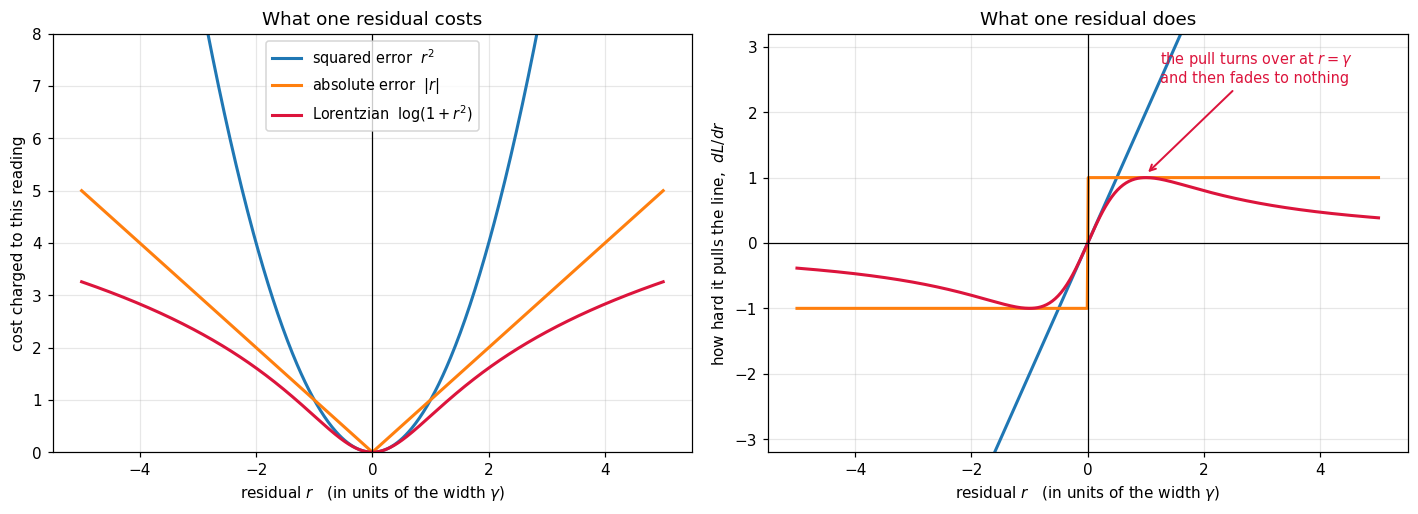

 residual  squared  absolute  Lorentzian       pull: squared  absolute  Lorentzian
      0.5     0.25      0.50        0.22                1.00      1.00      0.8000
        1     1.00      1.00        0.69                2.00      1.00      1.0000
        2     4.00      2.00        1.61                4.00      1.00      0.8000
        3     9.00      3.00        2.30                6.00      1.00      0.6000
        5    25.00      5.00        3.26               10.00      1.00      0.3846
       10   100.00     10.00        4.62               20.00      1.00      0.1980
      100 10000.00    100.00        9.21              200.00      1.00      0.0200


In [ ]:
r = np.linspace(-5, 5, 600)

#                     label                          cost            pull dL/dr        colour
losses = [("squared error  $r^2$",                   r**2,           2*r,              "tab:blue"),
          ("absolute error  $|r|$",                  np.abs(r),      np.sign(r),       "tab:orange"),
          (r"Lorentzian  $\log(1 + r^2)$",           np.log1p(r**2), 2*r/(1 + r**2),   "crimson")]

fig, (shape, pull) = plt.subplots(1, 2, figsize=(13, 4.8))
for label, cost, influence, colour in losses:
    shape.plot(r, cost, linewidth=2, color=colour, label=label)
    pull.plot(r, influence, linewidth=2, color=colour, label=label)

shape.set_ylim(0, 8)
shape.set_ylabel("cost charged to this reading")
shape.set_title("What one residual costs")
shape.legend(loc="upper center", fontsize=9.5)

pull.axhline(0, color="black", linewidth=0.8)
pull.set_ylim(-3.2, 3.2)
pull.set_ylabel("how hard it pulls the line,  $dL/dr$")
pull.set_title("What one residual does")
pull.annotate(r"the pull turns over at $r = \gamma$\nand then fades to nothing",
              xy=(1.0, 1.05), xytext=(1.25, 2.45), fontsize=9.5, color="crimson",
              arrowprops={"arrowstyle": "->", "color": "crimson", "linewidth": 1.3})

for axis in (shape, pull):
    axis.axvline(0, color="black", linewidth=0.8)
    axis.set_xlabel(r"residual $r$   (in units of the width $\gamma$)")
    axis.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"{'residual':>9}{'squared':>9}{'absolute':>10}{'Lorentzian':>12}"
      f"{'':6}{'pull: squared':>14}{'absolute':>10}{'Lorentzian':>12}")
for value in (0.5, 1, 2, 3, 5, 10, 100):
    print(f"{value:>9}{value**2:>9.2f}{value:>10.2f}{np.log1p(value**2):>12.2f}"
          f"{'':6}{2*value:>14.2f}{1.0:>10.2f}{2*value/(1 + value**2):>12.4f}")

The left panel is section 9's figure with a third curve added. The right panel is new, and it is
the one that matters.

**On the left, what a reading costs.** The Lorentzian barely charges for being wrong. A residual of
three widths costs 2.30 where squared error charges 9; a residual of a hundred widths costs 9.21
where squared error charges ten thousand. Near zero the three agree — at half a width the Lorentzian
asks 0.22 against squared error's 0.25 — so nothing is given away on the good readings.

**On the right, what a reading does.** This is the slope of the cost: how hard one point pulls the
fitted line. Squared error pulls harder the further out a point lies, without limit, which is why
section 9's single misreading dragged the fit. Absolute error pulls with a constant force of 1,
however badly a reading is wrong — that is the robustness section 9 bought.

The Lorentzian does something neither of them does. Its pull **rises, turns over at $r = \gamma$,
and then falls back towards zero**: 1.00 at one width, 0.198 at ten, 0.02 at a hundred. A reading
far enough out is not merely discounted, it is *ignored*. Losses that behave this way are called
**redescending**, and the behaviour is the whole point of them.

Whether that helps is not something section 9's misreadings can settle. A single mistyped value is
a blunder, not a noise model, and a loss derived from a Lorentzian deserves to be tried on readings
whose error really *is* Lorentzian. The next cell builds exactly that: the same spring, the same
twelve forces, the same width for the typical error — but a half-width now rather than a standard
deviation, and drawn from the distribution this section started from.

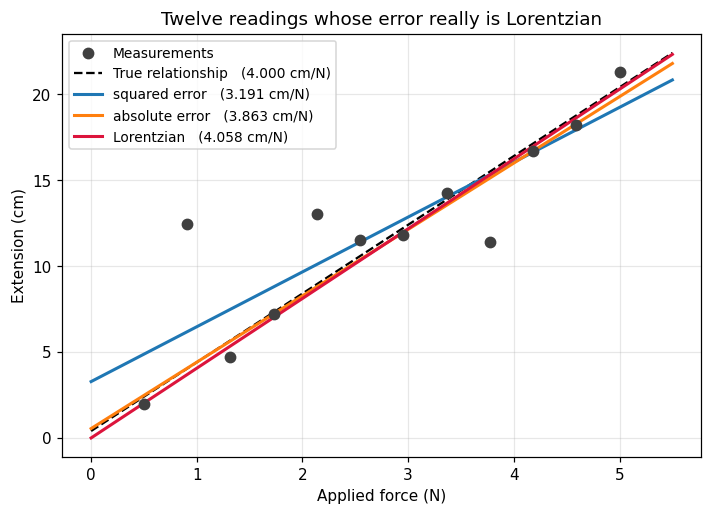

how far the fitted slope lands from the true 4.000 cm/N,
over 400 repeats of the whole experiment

loss the fit minimises                       median   90th pct       worst
squared error                                 0.366      2.707     226.827
absolute error                                0.171      0.470       1.498
Lorentzian   (scipy loss="cauchy")            0.145      0.416       1.245

the same Lorentzian loss once more, with the optimiser started from the
least-squares fit instead of from the absolute-error fit:
Lorentzian, started from least squares        0.147      0.423       7.663

half-width the algebra predicts for the least-squares slope: 0.369 cm/N


In [ ]:
from scipy.optimize import least_squares          # its `loss=` argument carries all three

# The same number, 0.6 cm, but now it is a *half-width* rather than a standard deviation:
# the same typical reading error, with tails that no Gaussian would ever produce.
gamma = noise_std


def robust_fit(f, x, guess):
    """Slope and intercept under the Lorentzian loss, searched for from a given start."""
    return tuple(least_squares(lambda p: x - (p[0] * f + p[1]), guess,
                               loss="cauchy", f_scale=gamma).x)


def three_fits(f, x):
    """Slope and intercept under each of the three losses, on the same readings."""
    squared = LinearRegression().fit(f.reshape(-1, 1), x)
    median_fit = QuantileRegressor(quantile=0.5, alpha=0, solver="highs").fit(f.reshape(-1, 1), x)
    absolute = (median_fit.coef_[0], median_fit.intercept_)
    return [(squared.coef_[0], squared.intercept_), absolute, robust_fit(f, x, absolute)]


def lorentzian_readings(generator):
    """Twelve readings of the same spring, with a Lorentzian error of half-width gamma."""
    return (100.0 / k_true) * force + offset_true + gamma * generator.standard_cauchy(force.shape)


# Its own generator, so the notebook's `rng` is left exactly where the earlier cells left it.
extension_heavy = lorentzian_readings(np.random.default_rng(33))

plt.figure(figsize=(7.5, 5))
plt.scatter(force, extension_heavy, s=45, color="0.25", zorder=4, label="Measurements")
plt.plot(F_line, (100 / k_true) * F_line + offset_true, "k--", linewidth=1.5,
         label=f"True relationship   ({100 / k_true:.3f} cm/N)")
for (slope, intercept), label, colour in zip(three_fits(force, extension_heavy),
                                             ["squared error", "absolute error", "Lorentzian"],
                                             ["tab:blue", "tab:orange", "crimson"]):
    plt.plot(F_line, slope * F_line + intercept, linewidth=2, color=colour,
             label=f"{label}   ({slope:.3f} cm/N)")
plt.xlabel("Applied force (N)")
plt.ylabel("Extension (cm)")
plt.title("Twelve readings whose error really is Lorentzian")
plt.grid(alpha=0.3)
plt.legend(fontsize=9)
plt.show()

# One draw settles nothing, so run the whole experiment 400 times and look at the errors.
trials = np.random.default_rng(3)
errors = []
for _ in range(400):
    x = lorentzian_readings(trials)
    slopes = [slope for slope, _ in three_fits(force, x)]
    slopes.append(robust_fit(force, x, np.polyfit(force, x, 1))[0])
    errors.append(np.abs(np.array(slopes) - 100.0 / k_true))
errors = np.array(errors)

def summarise(name, column):
    """One row: how far this loss's slope landed from the truth, across the 400 repeats."""
    print(f"{name:42}{np.median(errors[:, column]):>9.3f}"
          f"{np.percentile(errors[:, column], 90):>11.3f}{errors[:, column].max():>12.3f}")


print(f"how far the fitted slope lands from the true {100 / k_true:.3f} cm/N,")
print("over 400 repeats of the whole experiment\n")
print(f"{'loss the fit minimises':42}{'median':>9}{'90th pct':>11}{'worst':>12}")
summarise("squared error", 0)
summarise("absolute error", 1)
summarise('Lorentzian   (scipy loss="cauchy")', 2)

print("\nthe same Lorentzian loss once more, with the optimiser started from the")
print("least-squares fit instead of from the absolute-error fit:")
summarise("Lorentzian, started from least squares", 3)

weights = (force - force.mean()) / np.sum((force - force.mean()) ** 2)
print(f"\nhalf-width the algebra predicts for the least-squares slope: "
      f"{gamma * np.abs(weights).sum():.3f} cm/N")

Nine of the twelve readings sit almost on the true line. Three are thrown well off it. That is what
a Lorentzian reading error looks like in practice, and it is worth noticing that it does *not* look
like a noisy experiment — it looks like a clean one with three blunders in it.

The three fits divide accordingly. Squared error is dragged down to 3.191 cm/N; absolute error
recovers 3.863 and the Lorentzian 4.058, against a truth of 4.000.

One draw of twelve readings settles nothing, so the cell repeats the entire experiment four hundred
times. The median error falls from 0.366 cm/N under squared error to 0.171 under absolute error and
0.145 under the Lorentzian — but the column that carries the lesson is the last one. The worst of
the four hundred least-squares fits was wrong by 226.827 cm/N; the absolute error's worst was 1.498
and the Lorentzian's 1.245. (The block printed underneath the table runs the Lorentzian a second
time from a different starting point. That is a question about the optimiser rather than about the
loss, and it is taken up below.)

That is not bad luck, and no amount of extra data cures it. The least-squares slope is a fixed
weighted sum of the readings, and a weighted sum of Lorentzian variables is itself Lorentzian, so
the estimate inherits the distribution of the noise: **no mean, and no variance.** The cell prints
the half-width that algebra predicts for it, 0.369 cm/N, beside the measured median error of 0.366.
Under this noise least squares does not merely perform badly — the quantity it reports has no
expected value to be close to.

The gap between the two robust losses is far smaller, 0.171 against 0.145, and it is the one the
maximum likelihood argument actually promises: here the Lorentzian is the correct likelihood and the
absolute error is a near miss. Part of the difference is that an absolute-error fit to a straight
line is pinned by **two** of the readings — a property of the loss rather than an accident of these
numbers — so with twelve points it is a coarse instrument.

None of this touches leverage. Section 9's far-out misreading was never recognisable as an outlier
in $y$ — the line could tilt to accommodate it — and a redescending loss tilts as willingly as any
other. Only the design of the experiment answers that one.

**Where this is used in practice.** The Lorentzian earns its keep where the bad values are
**blunders** rather than heavy-tailed noise — a feature matched to the wrong point in another image,
a mistyped digit, a sensor that dropped out. Computer vision and robotics use it constantly, in
optical flow, bundle adjustment and SLAM, where a wrong correspondence is not a slightly unlucky
measurement but an answer from a different problem entirely. `scipy.optimize.least_squares` offers
it as `loss="cauchy"`, which is the call used above.

**And finance, where everyone knows the tails are fat?** The family is right and the Lorentzian is
the wrong member of it. Returns are routinely modelled with Student's $t$, whose degrees of freedom
$\nu$ act as a dial between Gaussian at $\nu \to \infty$ and Lorentzian at $\nu = 1$; fitted to real
return series, $\nu$ commonly lands between three and six. The Lorentzian sits at the extreme end of
that dial, and it is too far for the reason the table above has already shown in action: **a
Lorentzian has no mean and no variance.** Its $\gamma$ is a half-width, not a standard deviation.
Assume it and expected return, volatility and every ratio built from them stop existing — which is
a sharper way of saying "heavy-tailed" than any picture of a tail.

**So run the derivation on a Student's $t$ instead.** The same three steps give

$$
L(r) \;=\; \frac{\nu + 1}{2}\,\log\!\left(1 + \frac{r^2}{\nu\gamma^2}\right)
$$

which is the Lorentzian loss with the dial attached: at $\nu = 1$ it is exactly the loss plotted
above, and as $\nu \to \infty$ it becomes squared error, with $\gamma$ turning back into section
9's standard deviation $\sigma$ on the way. The pull now turns over at $r = \sqrt{\nu}\,\gamma$
rather than at $\gamma$, so a larger $\nu$ keeps listening to a reading further out before it
gives up on it. But it does still turn over, for **every** finite $\nu$.
There is no setting of the dial that buys back the convexity; there are only settings that move the
point at which the loss stops listening. And $\nu$ is a parameter of a likelihood like any other,
so it need not be guessed — estimating it from the data alongside the fit is standard practice.

**The price is paid at the optimiser, and it cannot be avoided.** Section 4.3 drew the squared-error
loss surface as a single bowl with one bottom, and said that was a special property. The Lorentzian
loses it: a loss whose pull descends cannot be convex, so the two properties come as a pair.

That is not an abstract worry. Suppose a lab notebook mixed up two springs.

In [ ]:
# Twelve readings taken on the 25 N/m spring, twelve more taken on a stiffer 50 N/m spring,
# and the two sets written down as one experiment. Its own generator, so the notebook's `rng`
# is left exactly where the earlier cells left it.
mixup = np.random.default_rng(11)
both_forces = np.concatenate([force, force])
both_extensions = np.concatenate([
    (100.0 / 25.0) * force + offset_true + mixup.normal(0, noise_std, force.shape),
    (100.0 / 50.0) * force + offset_true + mixup.normal(0, noise_std, force.shape)])

print(f"the two springs give slopes of {100/25:.1f} and {100/50:.1f} cm/N\n")
print(f"least squares:{'':20}slope {np.polyfit(both_forces, both_extensions, 1)[0]:.3f}"
      f"   — fits neither spring\n")
print("Lorentzian loss, started from different slopes:")
for start_slope in [0.0, 1.0, 2.0, 3.0, 4.0, 6.0]:
    slope, intercept = least_squares(
        lambda p: both_extensions - (p[0] * both_forces + p[1]),
        [start_slope, 0.0], loss="cauchy", f_scale=gamma).x
    print(f"   started at {start_slope:4.1f}  ->  slope {slope:6.3f}   intercept {intercept:6.3f}")

the two springs give slopes of 4.0 and 2.0 cm/N

least squares:                    slope 2.902   — fits neither spring

Lorentzian loss, started from different slopes:
   started at  0.0  ->  slope  4.075   intercept  0.053
   started at  1.0  ->  slope  1.809   intercept  1.061
   started at  2.0  ->  slope  1.809   intercept  1.061
   started at  3.0  ->  slope  1.809   intercept  1.061
   started at  4.0  ->  slope  4.075   intercept  0.053
   started at  6.0  ->  slope  4.075   intercept  0.053


Least squares splits the difference at 2.902 and describes neither spring. The Lorentzian refuses
to split the difference — and returns **two different answers**, 4.075 or 1.809, depending on
nothing but where the search started. Each is an excellent fit to one spring, reached by declaring
the other spring's twelve readings to be outliers.

That is redescending behaviour working exactly as designed, and it is why the result cannot be
trusted without care. A loss willing to ignore a distant reading is also willing to ignore half the
dataset.

The remedy is not to search harder for the global minimum. It is to start from a fit that can
already be trusted and descend to the nearest minimum from there, tightening $\gamma$ as you go.
That is safe for a reason worth knowing: the descent only ever lowers the cost, so the answer it
reaches survives at least as much bad data as the fit it started from. **The starting fit carries
the guarantee, and the descent inherits it.**

Which makes the requirement on that starting fit stronger than being convex: it has to be a fit
that a few bad readings cannot move. The absolute error is such a fit *here*, and the cell behind
the four-hundred-repeat table used it — worst result 1.245, against 7.663 started from least
squares, itself wrecked by these same tails. But it qualifies only because this experiment has no
leverage in it. One high-leverage reading moves an absolute-error fit as freely as it moves a
least-squares one, exactly as section 9's third row showed, and where that is a risk the starting
fit has to be chosen with more care than a twelve-point spring calibration ever needs. The point
that generalises is the order of operations, not the particular fit: robust first, redescending
second.

It is also why the cell just above had to be given a starting slope by hand before it would say
anything at all.

The half-width $\gamma$ is a further choice, and it is the one that fixes what counts as an
outlier. Like $\nu$ it can be estimated alongside the fit rather than guessed, and robust
statistics has standard machinery for doing exactly that — but `scipy` will not do it for you. Its
`f_scale` is a number you supply, and the cells above supplied the reading error this experiment
already knew.

So the honest summary, and the reason section 9 stops where it does:

| | convex | bounded pull | ignores far outliers |
|---|---|---|---|
| squared error | yes | no | no |
| absolute error | yes | yes | no |
| Lorentzian | **no** | yes | **yes** |

A Student's $t$ with any finite $\nu$ belongs on that bottom row too. The trade is not peculiar to
the Lorentzian; it is what redescending costs.

The step from squared to absolute error is the one to take when the shape of the noise is unknown:
it buys real protection against a misread value and keeps everything section 4.3 promised about the
loss surface. Go the whole way to the Lorentzian when there is a reason to — and the reason is a
noise model, as it was here — accepting that you trade away the guarantee that the answer you found
is the answer.

# 10. Basis expansion, and when linear regression is the wrong tool

One clarification first, because it disposes of the most common false objection.

**"Linear" means linear in the parameters, not in the inputs.** Fitting

$$
\hat{y} = \theta_0 + \theta_1 x + \theta_2 x^2 + \theta_3 x^3
$$

is still a linear regression problem: the parameters enter linearly, so we construct the new
features $x, x^2, x^3$ and fit exactly as before. This is called a **basis expansion**.
Mini-exercise 4 below applies it to the nonlinear spring of section 7.3, and the arc in the
residuals disappears; `02C` uses the same device to fit polynomials of degree fifteen.

So a curved relationship is not, on its own, a reason to reach for something else.

**It is a good choice when:**

- theory predicts a linear relationship, as with Hooke's law;
- the aim is to estimate a physically meaningful parameter;
- the dataset is small and interpretability matters;
- a simple, reliable baseline is needed before trying anything complicated.

**It is a poor choice when:**

- **you cannot guess which features to build.** Basis expansion works when the form is known or
  suspected — a quadratic term for a stiffening spring. When it is not, you are guessing, and the
  number of candidates grows fast: with ten inputs, all pairwise products already add fifty-five
  features. Class 7's networks are a way of *learning* the features instead of guessing them.
- **the relationship is discontinuous** — a threshold, a phase transition, a regime that switches.
  A smooth basis reproduces a smooth function well and a jump badly: it needs many terms and still
  oscillates around the step. This is the case basis expansion does not rescue, and it is exactly
  what decision trees in Class 4 handle naturally, since a tree is built from thresholds.
- the data contain many outliers, for the reasons section 9 showed;
- the input is an image, a sequence, a graph, or text.

That last case is worth stating clearly. Later classes are largely about inputs for which the very
notion of a linear coefficient per input variable makes no sense. A pixel intensity at position
$(37, 42)$ is not a scientific variable with a stable meaning across images.

<div class="alert alert-success">
<b>Mini-exercise 4 — A first basis expansion</b><br>
Return to the nonlinear spring data from Section 7.3.
<br><br>
1. Build a feature matrix with two columns, <code>force_wide</code> and <code>force_wide ** 2</code>. Hint: <code>np.column_stack</code>.<br>
2. Fit a <code>LinearRegression</code> to it.<br>
3. Plot the fitted curve over the data, and plot the residuals.<br>
4. Compare with the straight-line residuals in Section 7.3. Has the arc disappeared?<br>
5. Compare the fitted coefficient of the quadratic term with the value <code>-0.05</code> used to generate the data.
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 11. Common pitfalls

**Fitting before plotting.**
A straight line can be fitted to anything. Whether it *should* be is a question the scatter plot
answers and the fitting routine does not.

**Judging a fit by $R^2$ alone.**
$R^2$ is the MSE rescaled (section 7.4), so it cannot see anything the MSE cannot: a model with the
wrong shape can still score close to 1, as the straight line on section 7.3's stiffening spring
does. And it can only be compared between models fitted to the same data. Look at the residuals.

**Never looking at residuals.**
This is where systematic error becomes visible, and it costs one line of code.

**Forcing the line through the origin because theory says it should pass through it.**
Theory describes the physics; the intercept absorbs offsets in the *apparatus*. Removing it
transfers instrumental error into the slope, which is usually the quantity of interest.

**Reading coefficients causally.**
Especially with correlated features, where individual coefficients can be unstable and even change
sign, as Section 8.4 showed.

**Extrapolating beyond the fitted range.**
The spring obeyed Hooke's law up to 5 N and not at 12 N. A model is evidence only about the region
where data were collected.

**Forgetting that `X` must be two-dimensional in scikit-learn.**
Shape `(n,)` and shape `(n, 1)` are different, as notebook `01B` warned.

**Evaluating on the same data used for fitting.**
Every number computed in this notebook was measured on the training data. That is acceptable here
because our models had two parameters and no capacity to memorise. It stops being acceptable very
quickly, and `02C` explains why.

# 12. Applying this to your own data

Every method notebook in this course ends with the procedure for using the method, as runnable code.
This one cannot yet, and the reason is worth stating rather than hiding: **the protocol needs tools
that arrive in the next two notebooks.** Splitting, cross-validation and pipelines are `02C`;
searching a hyperparameter is `03C` §5. Writing the procedure here would mean using five things you
have not met, and it would have to leave out the step that matters most.

`03C` §8 is where it appears in full, and `04A` §13 repeats it with only the tuning block changed.
What this notebook contributes to it is two things.

**Linear regression's dial is which features, and in what basis.** It has no penalty strength, but
it has a model-selection problem — and section 8.3 has just met the reason training fit cannot solve it: it never falls when a
feature is added.
`02C` §1.2 and `03B` make degree the canonical example: the degree of a `PolynomialFeatures`
expansion is a hyperparameter *of a linear model*, chosen exactly as $\alpha$ will be. So when you
reach `03C` §8, read step 4 as "choose the flexibility", not "choose alpha".

> The classical route to choosing features is **best-subset and stepwise selection**, and it is not
> taught here. Stepwise has well-known problems: the selection is unstable, and the p-values and
> intervals reported afterwards are invalid because the same data chose the model. `03C` §4's lasso
> is the modern replacement, doing the selection as part of the fit rather than as a search before
> it — which is why this course motivates regularization through bias and variance rather than
> through subset search.

**And it contributes the reason there is a protocol at all.** Section 8.3 met a score that can only go up
as features are added, because it is computed on the data the model was fitted to. A number like
that cannot be trusted to compare models, and that is the premise the whole procedure is built on.

# 13. Final exercises

<div class="alert alert-success">
<b>Exercise 1 — A calibration experiment</b><br>
A thermocouple produces a voltage that depends on temperature. You have the following calibration data:
<br><br>
<code>temperature = np.array([0, 20, 40, 60, 80, 100, 120, 140, 160, 180])</code>  # °C<br>
<code>voltage = np.array([0.02, 0.81, 1.63, 2.38, 3.24, 4.01, 4.83, 5.59, 6.44, 7.19])</code>  # mV
<br><br>
1. Plot the data.<br>
2. Fit a straight line and report the slope with its units.<br>
3. Plot the residuals. Is a linear calibration adequate?<br>
4. Use the fitted model to estimate the temperature corresponding to a reading of 3.00 mV.<br>
5. Would you trust the model at 400 °C? Explain.
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

<div class="alert alert-success">
<b>Exercise 2 — Noise, sample size and reliability</b><br>
Write a small numerical experiment that investigates how reliably the spring constant is recovered.
<br><br>
1. Write a function that generates a synthetic spring dataset with given <code>n_points</code> and <code>noise_std</code>, fits a line, and returns the estimated <code>k</code>.<br>
2. Run it 200 times for <code>n_points = 12</code> and <code>noise_std = 0.15</code>. Plot a histogram of the estimates.<br>
3. Repeat for <code>n_points = 100</code>. How does the histogram change?<br>
4. Repeat for <code>noise_std = 0.5</code> with <code>n_points = 12</code>.<br>
5. State in one sentence how the spread of the estimates depends on the number of measurements and on the measurement error.
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

<div class="alert alert-success">
<b>Exercise 3 — Choosing a model honestly</b><br>
Using the diabetes dataset from Section 8:
<br><br>
1. Fit linear regressions using 1, 2, 5 and then all 10 features, and record the <code>R2</code> of each.<br>
2. Plot <code>R2</code> against the number of features.<br>
3. Does <code>R2</code> ever decrease when a feature is added? Explain why not.<br>
4. Given part 3, explain why <code>R2</code> measured on the training data cannot be used to choose how many features to include.
<br><br>
Part 4 is the question `02C` is built around, so it is worth thinking about before you get there.
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# Key Takeaways

- Supervised learning has four parts: features and targets, a model family, a loss function, and an optimization that fits the parameters.
- Fitting a model means minimising a loss. Every method in this course is a variation on that idea.
- Linear regression with squared error is convex: it has exactly one minimum and an exact solution.
- The scikit-learn pattern `model.fit(X, y)` then `model.predict(X_new)` is used by every model in the library, and `X` must always be two-dimensional.
- In scientific work, regression coefficients often *are* the result, carrying units and physical meaning.
- Residual plots reveal systematic error that summary statistics and fitted-line plots hide.
- Structure in the residuals means the model is missing something real.
- Least squares is maximum likelihood under Gaussian noise. The choice of loss is an assumption about the noise, which is why outliers distort a least squares fit.
- An observation's influence depends on where it sits in the input range as well as on how wrong it is. Points at the extremes have the most leverage over the slope.
- Correlated features make individual coefficients unstable and unsafe to interpret.
- "Linear" means linear in the parameters. Basis expansion extends the method to curves.
- Every quality measure in this notebook was computed on the training data, which is not a safe practice in general.

# Optional preparation for the next notebook

Before the next notebook, students should be comfortable with:

- the meaning of features, targets, model and loss;
- reshaping a one-dimensional array to shape `(n, 1)`;
- the `fit` / `predict` pattern in scikit-learn;
- plotting a fitted model on top of the data;
- computing and plotting residuals.

Notebook `02B` keeps this entire framework and changes one thing: the target becomes a
**category** rather than a number. We will see what has to change as a result, and what does not.